
**Predicting Medication Management Difficulty Using Machine Learning**

2021 National Consumer Survey on Medication Experiences & Pharmacists' Roles (NCSME)


**Author:** Diana Opiyo

**Dataset:** N = 1,521 | **Target:** Med_Difficult (Binary Classification)

**Models:** Logistic Regression | Random Forest | Support Vector Machine | XGBoost

**Study Overview**

This notebook builds and evaluates machine learning models to predict which patients are at HIGH RISK of medication management difficulty, enabling pharmacists to proactively identify vulnerable patients for targeted intervention.

**Notebook Structure**

**Phase 0** — Import Libraries

**Phase 1** — Data Loading, Cleaning & Exploration

**Phase 2** — Feature Engineering & Target Binarization

**Phase 3** — SMOTE (Class Imbalance Correction)

**Phase 4** — Model Building & Hyperparameter Tuning

**Phase 5** — Rigorous Evaluation (ROC-AUC, Cross-Validation, McNemar's Test)

**Phase 6** — Interpretability (Feature Importance, SHAP, Odds Ratios)

**Phase 7** — Publication-Ready Tables & Figures


In [3]:
!pip install xgboost statsmodels

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


---
# PHASE 0 — IMPORT LIBRARIES

In [6]:
# ═════════════════════════════════════════════════════════════════
# CELL 0: IMPORT ALL REQUIRED LIBRARIES
# ═════════════════════════════════════════════════════════════════
# We import all libraries at the top of the notebook so that
# dependencies are visible in one place and any missing package
# errors are caught immediately before running any analysis.
#
# Library purposes:
#   pandas       → data loading, manipulation, and table creation
#   numpy        → numerical operations and array handling
#   matplotlib   → base plotting library
#   seaborn      → statistical data visualization (built on matplotlib)
#   scipy.stats  → statistical tests (t-test, McNemar's test)
#   sklearn      → machine learning models, preprocessing, evaluation
#   xgboost      → gradient boosting model (install: pip install xgboost)
#   warnings     → suppress non-critical warning messages
# ═════════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency

# Preprocessing & model selection
from sklearn.model_selection import (train_test_split, GridSearchCV,
                                     cross_val_score, StratifiedKFold,
                                     learning_curve)
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

# Evaluation metrics
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             roc_curve, auc, precision_recall_curve,
                             average_precision_score, roc_auc_score,
                             brier_score_loss)

from sklearn.calibration import calibration_curve

import warnings
warnings.filterwarnings('ignore')

# Set global plot style
plt.rcParams.update({
    'font.family'     : 'serif',
    'font.size'       : 11,
    'axes.titlesize'  : 12,
    'axes.labelsize'  : 11,
    'figure.dpi'      : 150
})



---
# PHASE 1 — DATA LOADING, CLEANING & EXPLORATION

In [7]:
# ═════════════════════════════════════════════════════════════════
# CELL 1.1: LOAD THE DATASET
# ═════════════════════════════════════════════════════════════════
# We read the 2021 NCSME Excel file into a pandas DataFrame.
# A DataFrame is a two-dimensional table where:
# ═════════════════════════════════════════════════════════════════

df_raw = pd.read_excel('/content/drive/MyDrive/Medication difficulty/NCSME_PR.xlsx')

print(f"   Rows (respondents) : {df_raw.shape[0]}")
print(f"   Columns (variables): {df_raw.shape[1]}")
print("\nFirst 3 rows preview:")
df_raw.head(3)



   Rows (respondents) : 1521
   Columns (variables): 184

First 3 rows preview:


,StartDate,EndDate,IPAddress,Duration__in_seconds_,RecordedDate,LocationLatitude,LocationLongitude,YearBorn,State,RuralUrban,...,Black,Hispanic,Islander,White,OtherEthnic,OtherEthnicDESC,Marital,HouseIncome,Education,Comments
0,2021-04-16 12:09:21,2021-04-16 12:14:57,69.119.220.179,335,2021-04-16 12:14:57,40.820496,-73.918297,1977,33,1,...,1.0,NaN,NaN,NaN,NaN,NaN,3,4,4,Great survey
1,2021-04-16 12:18:42,2021-04-16 12:26:58,174.197.144.250,495,2021-04-16 12:26:58,40.676407,-73.875298,1992,33,1,...,NaN,NaN,NaN,1.0,NaN,NaN,1,6,1,NaN
2,2021-04-16 12:17:21,2021-04-16 12:31:27,173.91.123.76,845,2021-04-16 12:31:28,41.105392,-80.690498,1980,36,1,...,NaN,NaN,NaN,1.0,NaN,NaN,1,2,1,NaN


In [8]:
# ═════════════════════════════════════════════════════════════════
# CELL 1.2: SELECT VARIABLES OF INTEREST
# ═════════════════════════════════════════════════════════════════
# The raw dataset contains 184 columns. We retain only the 16
# variables relevant to our research framework (15 predictors +
# 1 target). All other columns are dropped.
#
# PREDICTOR CATEGORIES (from concept paper):
# ┌─────────────────────┬────────────────────────────────────────┐
# │ Category            │ Variables                              │
# ├─────────────────────┼────────────────────────────────────────┤
# │ Medication Complexity│ NumRx, NumOTC, NumHerbal              │
# │ Health Burden       │ NumHealthProb, RateHealth, HospLastYear│
# │ Barriers            │ Fin_Hardship, Transport, Side_Effects  │
# │ Support Systems     │ Social_Support, Fam_Friend             │
# │ Demographics        │ YearBorn, Education, HouseIncome,      │
# │                     │ RuralUrban                             │
# ├─────────────────────┼────────────────────────────────────────┤
# │ TARGET              │ Med_Difficult                          │
# └─────────────────────┴────────────────────────────────────────┘
# ═════════════════════════════════════════════════════════════════

KEEP_COLS = [
    # Medication complexity
    'NumRx', 'NumOTC', 'NumHerbal',
    # Health burden
    'NumHealthProb', 'RateHealth', 'HospLastYear',
    # Barriers
    'Fin_Hardship', 'Transport', 'Side_Effects',
    # Support systems
    'Social_Support', 'Fam_Friend',
    # Demographics
    'YearBorn', 'Education', 'HouseIncome', 'RuralUrban',
    # Target variable
    'Med_Difficult'
]

df = df_raw[KEEP_COLS].copy()

print(f"   Dropped: {df_raw.shape[1] - len(df.columns)} columns")
print(f"\nRetained columns: {df.columns.tolist()}")



   Dropped: 168 columns

Retained columns: ['NumRx', 'NumOTC', 'NumHerbal', 'NumHealthProb', 'RateHealth', 'HospLastYear', 'Fin_Hardship', 'Transport', 'Side_Effects', 'Social_Support', 'Fam_Friend', 'YearBorn', 'Education', 'HouseIncome', 'RuralUrban', 'Med_Difficult']


In [10]:
# ═════════════════════════════════════════════════════════════════
# CELL 1.3: CHECK FOR MISSING VALUES
# ═════════════════════════════════════════════════════════════════
# Missing data must be identified before any modeling. If missing
# values exist, they must be handled via imputation or deletion.
# We check each column for null/NaN values and report the count
# and percentage of missing per variable.
# ═════════════════════════════════════════════════════════════════

missing_count = df.isnull().sum()
missing_pct   = (missing_count / len(df) * 100).round(2)

missing_report = pd.DataFrame({
    'Missing Count'  : missing_count,
    'Missing Percent': missing_pct
})

print("Missing Value Report:")
print(missing_report)
print(f"\nTotal missing cells: {missing_count.sum()}")

if missing_count.sum() == 0:
    print("No missing values.")
else:
    print(" Missing values detected — imputation required before modeling.")



Missing Value Report:
                Missing Count  Missing Percent
NumRx                       0              0.0
NumOTC                      0              0.0
NumHerbal                   0              0.0
NumHealthProb               0              0.0
RateHealth                  0              0.0
HospLastYear                0              0.0
Fin_Hardship                0              0.0
Transport                   0              0.0
Side_Effects                0              0.0
Social_Support              0              0.0
Fam_Friend                  0              0.0
YearBorn                    0              0.0
Education                   0              0.0
HouseIncome                 0              0.0
RuralUrban                  0              0.0
Med_Difficult               0              0.0

Total missing cells: 0
No missing values.


In [12]:
# ═════════════════════════════════════════════════════════════════
# CELL 1.4: OUTLIER ANALYSIS & WINSORIZATION
# ═════════════════════════════════════════════════════════════════
# Count-based variables (NumRx, NumOTC, NumHerbal, NumHealthProb)
# contain extreme values likely caused by data entry errors
# (e.g., NumRx=70, NumHerbal=50). These outliers can distort
# model training by pulling decision boundaries toward rare extremes.
#
# APPROACH — WINSORIZATION at the 99th percentile:
#   - Values ABOVE the 99th percentile are CAPPED at that threshold
#   - The respondent is RETAINED in the dataset (no data loss)
#   - This is preferred over deletion for small clinical datasets
#
# Likert scale variables (1–7) are NOT winsorized since their
# range is already bounded by the survey instrument design.
# ═════════════════════════════════════════════════════════════════

count_vars = ['NumRx', 'NumOTC', 'NumHerbal', 'NumHealthProb']

winsorize_report = []
for col in count_vars:
    original_max = df[col].max()
    p99          = df[col].quantile(0.99)
    n_capped     = (df[col] > p99).sum()
    df[col]      = df[col].clip(upper=p99)   # cap values at 99th percentile

    winsorize_report.append({
        'Variable'           : col,
        'Original Max'       : int(original_max),
        '99th Percentile Cap': p99,
        'N Values Capped'    : n_capped
    })

print("Winsorization Report (Count Variables):")
print(pd.DataFrame(winsorize_report).to_string(index=False))



Winsorization Report (Count Variables):
     Variable  Original Max  99th Percentile Cap  N Values Capped
        NumRx            14                 14.0                0
       NumOTC             7                  7.0                0
    NumHerbal            10                 10.0                0
NumHealthProb            10                 10.0                0


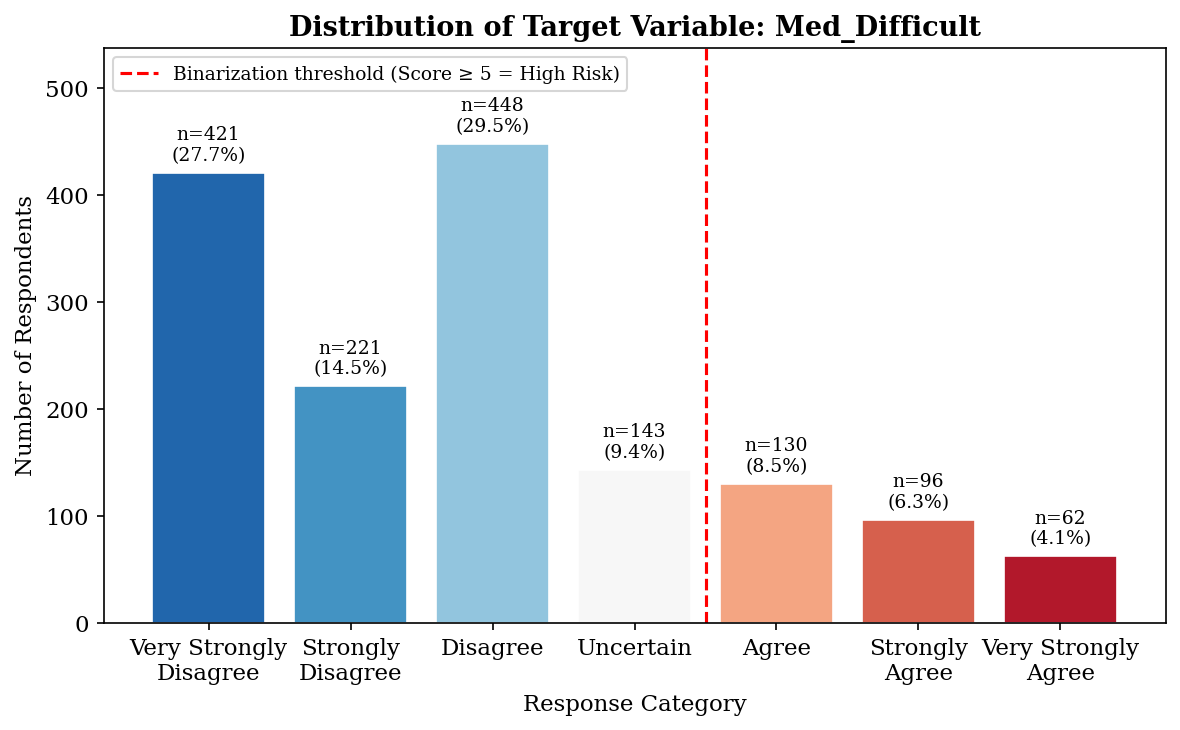

Mean  : 2.92
Median: 3
Mode  : 3


In [17]:
# ═════════════════════════════════════════════════════════════════
# CELL 1.5: RAW TARGET VARIABLE EXPLORATION
# ═════════════════════════════════════════════════════════════════
# Med_Difficult measures: "Using medications as instructed is difficult"
# Measured on a 7-point Likert scale:
#   1 = Very Strongly Disagree
#   2 = Strongly Disagree
#   3 = Disagree
#   4 = Uncertain
#   5 = Agree
#   6 = Strongly Agree
#   7 = Very Strongly Agree
#
# We visualize the raw distribution before binarization to
# understand the spread of responses across all 7 levels.
# ═════════════════════════════════════════════════════════════════

likert_labels = {
    1: 'Very Strongly\nDisagree',
    2: 'Strongly\nDisagree',
    3: 'Disagree',
    4: 'Uncertain',
    5: 'Agree',
    6: 'Strongly\nAgree',
    7: 'Very Strongly\nAgree'
}

counts = df['Med_Difficult'].value_counts().sort_index()
colors_likert = ['#2166ac','#4393c3','#92c5de','#f7f7f7','#f4a582','#d6604d','#b2182b']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(
    [likert_labels[i] for i in counts.index],
    counts.values,
    color=colors_likert, edgecolor='white', linewidth=0.8
)
# Add count labels on bars
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 8,
            f'n={val}\n({val/len(df)*100:.1f}%)',
            ha='center', va='bottom', fontsize=9)

ax.set_title(
    'Distribution of Target Variable: Med_Difficult',
    fontsize=13, fontweight='bold'
)
ax.set_xlabel('Response Category', fontsize=11)
ax.set_ylabel('Number of Respondents', fontsize=11)
ax.set_ylim(0, counts.max() * 1.2)

# Add vertical line separating "not difficult" from "difficult"
ax.axvline(x=3.5, color='red', linestyle='--', linewidth=1.5,
           label='Binarization threshold (Score ≥ 5 = High Risk)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('fig0_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Mean  : {df['Med_Difficult'].mean():.2f}")
print(f"Median: {df['Med_Difficult'].median():.0f}")
print(f"Mode  : {df['Med_Difficult'].mode()[0]}")



---
# PHASE 2 — FEATURE ENGINEERING & TARGET BINARIZATION

In [18]:
# ═════════════════════════════════════════════════════════════════
# CELL 2.1: DERIVE AGE FROM YEARBORNCODE
# ═════════════════════════════════════════════════════════════════
# YearBorn is the raw birth year (1932–2003). We subtract from
# the survey year (2021) to derive actual age in years.
#
# Why continuous Age instead of age groups?
#   - Preserves full variation in the data
#   - Avoids arbitrary group boundary decisions
#   - Allows the model to detect non-linear age effects
#   - Age as a continuous variable is standard in clinical ML
# ═════════════════════════════════════════════════════════════════

# Derive continuous age from birth year
df['Age'] = 2021 - df['YearBorn']

# Drop YearBorn — Age replaces it
df.drop(columns=['YearBorn'], inplace=True)

print("Age derived from YearBorn (Survey year = 2021)")
print(f"   Minimum age : {df['Age'].min()} years")
print(f"   Maximum age : {df['Age'].max()} years")
print(f"   Mean age    : {df['Age'].mean():.1f} years")
print(f"   Std dev     : {df['Age'].std():.1f} years")



Age derived from YearBorn (Survey year = 2021)
   Minimum age : 18 years
   Maximum age : 89 years
   Mean age    : 53.9 years
   Std dev     : 17.3 years


In [19]:
# ═════════════════════════════════════════════════════════════════
# CELL 2.2: FEATURE ENGINEERING — COMPOSITE SCORES
# ═════════════════════════════════════════════════════════════════
# We create four theoretically-motivated composite scores by
# summing variables within each conceptual category. These composite features:
#
#   1. Reduce dimensionality within each domain
#   2. Are theoretically correct
#   3. Can capture combined burden effects that individual items miss
#
# Note: We retain the ORIGINAL individual variables alongside
# the composites and let the model determine which are most
# predictive via feature importance analysis.
#
#   Total_Meds    = NumRx + NumOTC + NumHerbal
#                   → Total daily medication burden
#
#   Barrier_Score = Fin_Hardship + Transport + Side_Effects
#                   → Combined barrier index (higher = more barriers)
#
#   Support_Score = Social_Support + Fam_Friend
#                   → Combined support index (higher = more support)
#
#   Health_Score  = NumHealthProb + RateHealth + HospLastYear
#                   → Combined health burden index
# ═════════════════════════════════════════════════════════════════

df['Total_Meds']    = df['NumRx'] + df['NumOTC'] + df['NumHerbal']
df['Barrier_Score'] = df['Fin_Hardship'] + df['Transport'] + df['Side_Effects']
df['Support_Score'] = df['Social_Support'] + df['Fam_Friend']
df['Health_Score']  = df['NumHealthProb'] + df['RateHealth'] + df['HospLastYear']

print(f"   Total_Meds    — range: {df['Total_Meds'].min():.0f} to {df['Total_Meds'].max():.0f}")
print(f"   Barrier_Score — range: {df['Barrier_Score'].min():.0f} to {df['Barrier_Score'].max():.0f}")
print(f"   Support_Score — range: {df['Support_Score'].min():.0f} to {df['Support_Score'].max():.0f}")
print(f"   Health_Score  — range: {df['Health_Score'].min():.0f} to {df['Health_Score'].max():.0f}")



   Total_Meds    — range: 0 to 31
   Barrier_Score — range: 3 to 21
   Support_Score — range: 2 to 14
   Health_Score  — range: 2 to 16



   Low Risk  (0, scores 1–4): 1,233 patients (81.1%)
   High Risk (1, scores 5–7): 288 patients (18.9%)


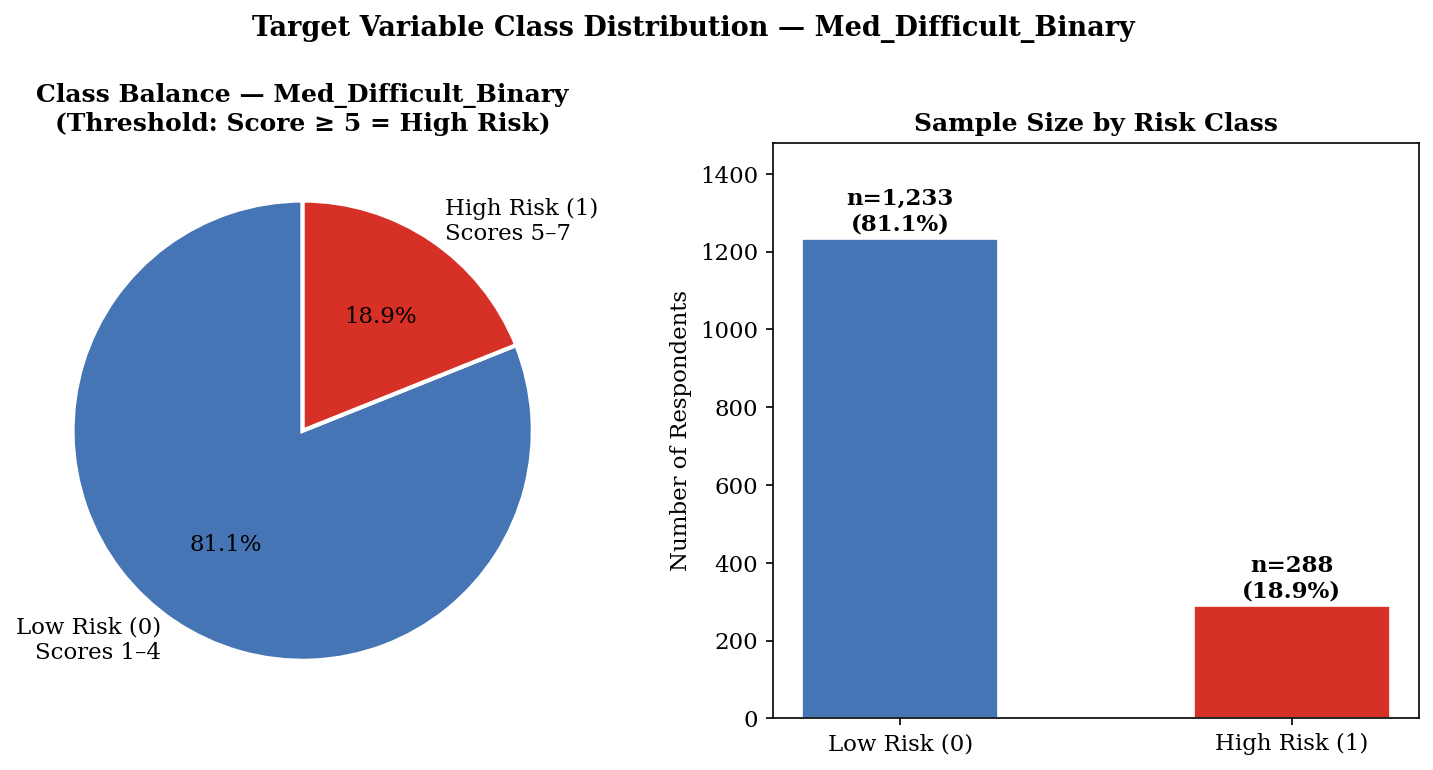

Saved as 'fig1_class_balance.png'


In [20]:
# ═════════════════════════════════════════════════════════════════
# CELL 2.3: BINARIZE THE TARGET VARIABLE
# ═════════════════════════════════════════════════════════════════
# Med_Difficult uses a 7-point Likert scale where:
#   1–3 = Various levels of disagreement (NOT difficult)
#   4   = Uncertain (neither agree nor disagree)
#   5–7 = Various levels of agreement (IS difficult)
#
# THRESHOLD DECISION: Score ≥ 5 (Agree and above)
#
# Justification: A patient is classified as High Risk ONLY when
# they ACTIVELY AGREE that medications are difficult to use.
# Score 4 (Uncertain) is classified as Low Risk because:
#   - Uncertainty ≠ confirmed difficulty
#   - Clinical interventions should target confirmed difficulty
#   #   - It aligns with how pharmacists would interpret the scale
#
#   Scores 1–4  →  0 = Low Risk
#   Scores 5–7  →  1 = High Risk
# ═════════════════════════════════════════════════════════════════

df['Med_Difficult_Binary'] = (df['Med_Difficult'] >= 5).astype(int)

counts = df['Med_Difficult_Binary'].value_counts().sort_index()
n_total = len(df)

print(f"\n   Low Risk  (0, scores 1–4): {counts[0]:,} patients ({counts[0]/n_total*100:.1f}%)")
print(f"   High Risk (1, scores 5–7): {counts[1]:,} patients ({counts[1]/n_total*100:.1f}%)")

# Visualize class balance
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Pie chart
axes[0].pie(
    counts, labels=['Low Risk (0)\nScores 1–4', 'High Risk (1)\nScores 5–7'],
    autopct='%1.1f%%', colors=['#4575b4', '#d73027'],
    startangle=90, wedgeprops=dict(edgecolor='white', linewidth=2),
    textprops={'fontsize': 11}
)
axes[0].set_title('Class Balance — Med_Difficult_Binary\n(Threshold: Score ≥ 5 = High Risk)',
                  fontsize=12, fontweight='bold')

# Bar chart with counts
bar_colors = ['#4575b4', '#d73027']
bars = axes[1].bar(['Low Risk (0)', 'High Risk (1)'], counts.values,
                   color=bar_colors, edgecolor='white', linewidth=0.8, width=0.5)
for bar, val in zip(bars, counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 10,
                 f'n={val:,}\n({val/n_total*100:.1f}%)',
                 ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[1].set_title('Sample Size by Risk Class', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Number of Respondents', fontsize=11)
axes[1].set_ylim(0, counts.max() * 1.2)

plt.suptitle('Target Variable Class Distribution — Med_Difficult_Binary',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig1_class_balance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved as 'fig1_class_balance.png'")



In [21]:
# ═════════════════════════════════════════════════════════════════
# CELL 2.4: DEFINE FINAL FEATURE SET (PREDICTORS)
# ═════════════════════════════════════════════════════════════════
# We define the final list of predictor variables used in modeling.
# This includes both original variables AND composite scores.
# The target variable is defined separately.
# ═════════════════════════════════════════════════════════════════

PREDICTORS = [
    # Medication complexity (original)
    'NumRx', 'NumOTC', 'NumHerbal',
    # Health burden (original)
    'NumHealthProb', 'RateHealth', 'HospLastYear',
    # Barriers (original)
    'Fin_Hardship', 'Transport', 'Side_Effects',
    # Support systems (original)
    'Social_Support', 'Fam_Friend',
    # Demographics
    'Age', 'Education', 'HouseIncome', 'RuralUrban',
    # Composite scores (engineered features)
    'Total_Meds', 'Barrier_Score', 'Support_Score', 'Health_Score'
]

TARGET = 'Med_Difficult_Binary'

# Readable label map
LABEL_MAP = {
    'NumRx'        : 'Prescription Drugs (n)',
    'NumOTC'       : 'OTC Medications (n)',
    'NumHerbal'    : 'Herbal Supplements (n)',
    'NumHealthProb': 'No. of Health Problems',
    'RateHealth'   : 'Self-Rated Health (1=Exc, 4=Poor)',
    'HospLastYear' : 'Hospitalized Last Year (1=Yes)',
    'Fin_Hardship' : 'Financial Hardship (1–7)',
    'Transport'    : 'Transportation Barrier (1–7)',
    'Side_Effects' : 'Side Effects (1–7)',
    'Social_Support': 'Social Support (1–7)',
    'Fam_Friend'   : 'Relies on Family/Friends (1–7)',
    'Age'          : 'Age (years)',
    'Education'    : 'Education Level (1–7)',
    'HouseIncome'  : 'Household Income (1–8)',
    'RuralUrban'   : 'Geographic Area (1=Urban)',
    'Total_Meds'   : 'Total Medications (composite)',
    'Barrier_Score': 'Barrier Score (composite)',
    'Support_Score': 'Support Score (composite)',
    'Health_Score' : 'Health Burden Score (composite)'
}

X = df[PREDICTORS].copy()
y = df[TARGET].copy()

print(f"Feature matrix (X) shape : {X.shape}  (patients × features)")
print(f"   Target vector (y)  shape : {y.shape}")
print(f"\n   Total predictors: {len(PREDICTORS)}")
print(f"   Original variables  : 15")
print(f"   Composite features  : 4")



Feature matrix (X) shape : (1521, 19)  (patients × features)
   Target vector (y)  shape : (1521,)

   Total predictors: 19
   Original variables  : 15
   Composite features  : 4


---
# PHASE 1 — DESCRIPTIVE STATISTICS & CORRELATION

In [23]:
# ═════════════════════════════════════════════════════════════════
# CELL 1.6: TABLE 1 — DESCRIPTIVE STATISTICS BY RISK GROUP
# ═════════════════════════════════════════════════════════════════
# Table 1 is a mandatory element in every clinical research paper.
# It describes the characteristics of the study sample broken down
# by outcome group (Low Risk vs High Risk).
#
# For each predictor variable we report:
#   Mean ± Standard Deviation for each group
#   Independent samples t-test p-value
#   Significance: *** p<0.001  ** p<0.01  * p<0.05  ns=not significant
#
# A significant p-value indicates the variable statistically
# distinguishes between risk groups.
# Non-significant variables are still retained as the model may
# find non-linear combinations that the t-test cannot detect.
# ═════════════════════════════════════════════════════════════════

low_risk  = df[df[TARGET] == 0]
high_risk = df[df[TARGET] == 1]
n_low     = len(low_risk)
n_high    = len(high_risk)

print(f"Low Risk  group (0): n = {n_low:,}")
print(f"High Risk group (1): n = {n_high:,}")
print()

# Build Table 1 using original 15 predictors
ORIG_PREDICTORS = [
    'NumRx','NumOTC','NumHerbal','NumHealthProb','RateHealth',
    'HospLastYear','Fin_Hardship','Transport','Side_Effects',
    'Social_Support','Fam_Friend','Age','Education','HouseIncome','RuralUrban'
]

table1_rows = []
for col in ORIG_PREDICTORS:
    l_mean, l_std = low_risk[col].mean(), low_risk[col].std()
    h_mean, h_std = high_risk[col].mean(), high_risk[col].std()
    t_stat, p_val = stats.ttest_ind(low_risk[col].dropna(),
                                     high_risk[col].dropna())
    sig = ('***' if p_val < 0.001 else
           ('**'  if p_val < 0.01  else
           ('*'   if p_val < 0.05  else 'ns')))
    table1_rows.append({
        'Variable'                         : LABEL_MAP[col],
        f'Low Risk (n={n_low}) Mean ± SD'  : f"{l_mean:.2f} ± {l_std:.2f}",
        f'High Risk (n={n_high}) Mean ± SD': f"{h_mean:.2f} ± {h_std:.2f}",
        'p-value'                          : f"{p_val:.4f}",
        'Sig.'                             : sig
    })

table1_df = pd.DataFrame(table1_rows)

print("TABLE 1 — Characteristics of Study Sample by Medication Difficulty Risk Group")
print("=" * 100)
print(table1_df.to_string(index=False))
print("\nNote: *** p<0.001  ** p<0.01  * p<0.05  ns = not significant")
print("      Independent samples t-test. Values are Mean ± Standard Deviation.")

# Save to CSV (ready for word processor)
table1_df.to_csv('table1_descriptive_stats.csv', index=False)




Low Risk  group (0): n = 1,233
High Risk group (1): n = 288

TABLE 1 — Characteristics of Study Sample by Medication Difficulty Risk Group
                         Variable Low Risk (n=1233) Mean ± SD High Risk (n=288) Mean ± SD p-value Sig.
           Prescription Drugs (n)                 2.95 ± 3.04                 2.74 ± 2.87  0.2749   ns
              OTC Medications (n)                 1.25 ± 1.49                 1.43 ± 1.46  0.0600   ns
           Herbal Supplements (n)                 1.03 ± 1.91                 1.25 ± 1.72  0.0752   ns
           No. of Health Problems                 2.25 ± 2.09                 2.12 ± 2.04  0.3686   ns
Self-Rated Health (1=Exc, 4=Poor)                 2.24 ± 0.69                 2.15 ± 0.79  0.0355    *
   Hospitalized Last Year (1=Yes)                 1.86 ± 0.34                 1.74 ± 0.44  0.0000  ***
         Financial Hardship (1–7)                 3.12 ± 1.68                 5.11 ± 1.64  0.0000  ***
     Transportation Barrier (1–7)    

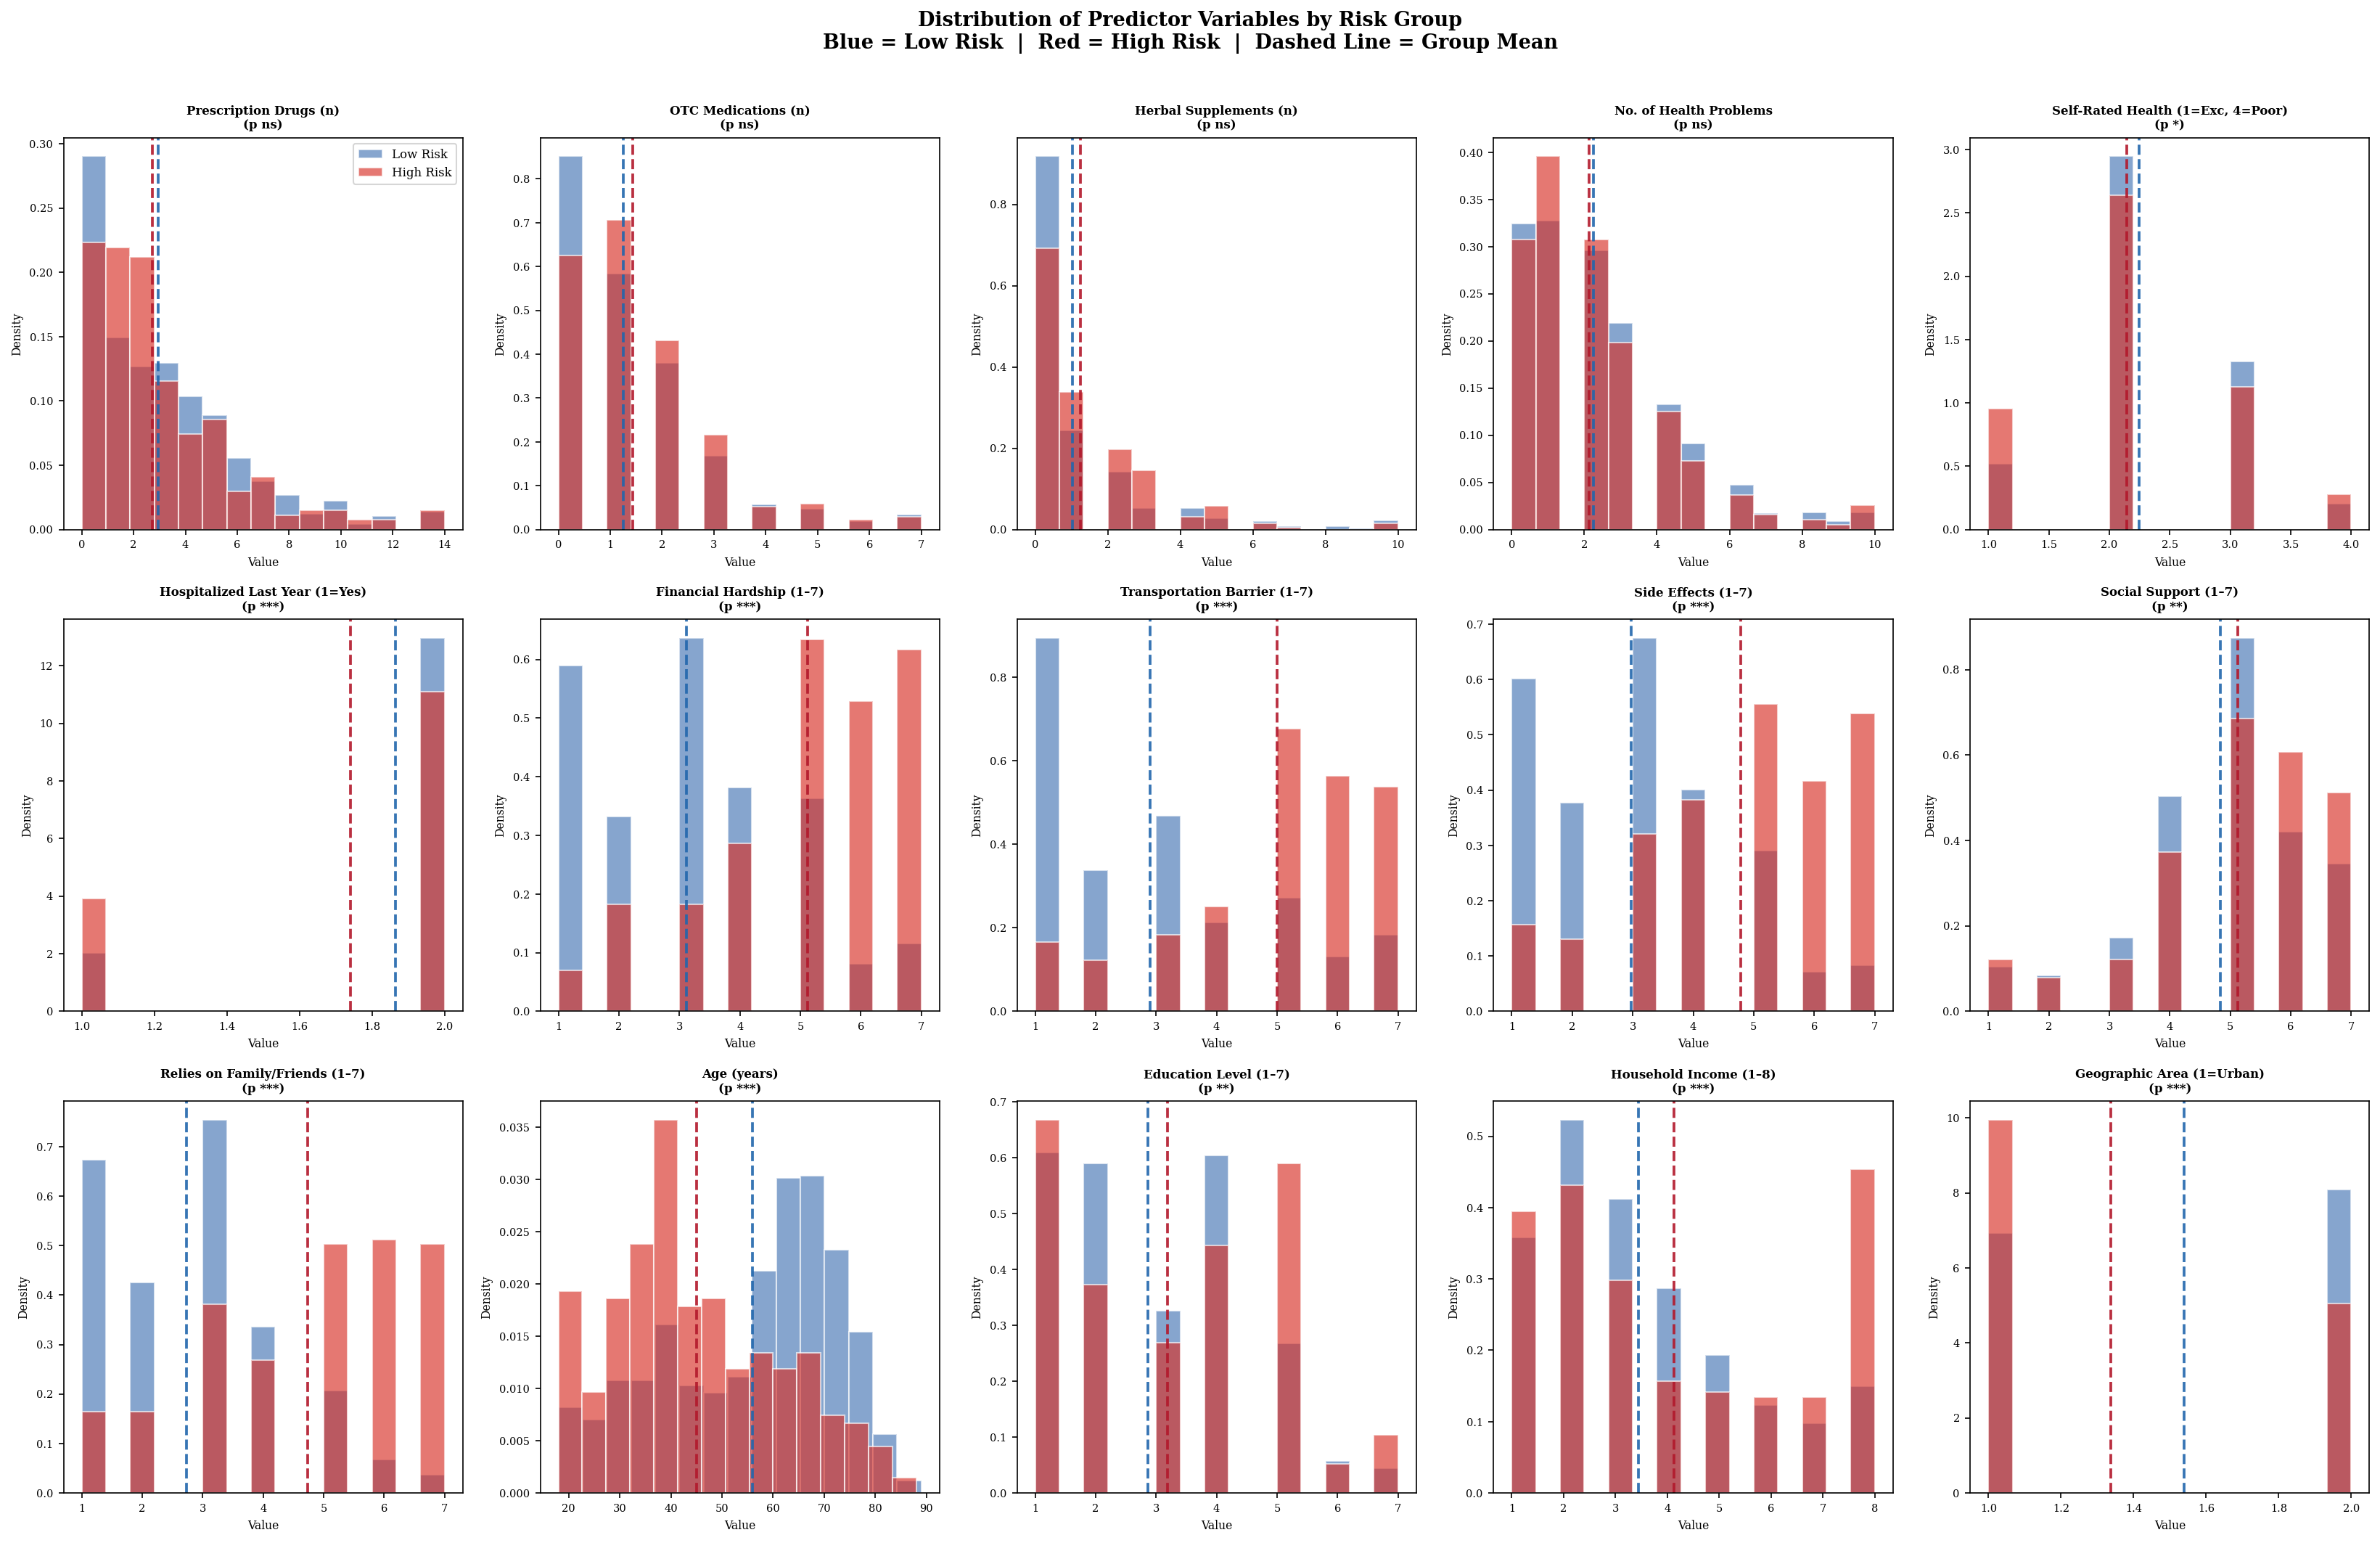

In [25]:
# ═════════════════════════════════════════════════════════════════
# CELL 1.7: VARIABLE DISTRIBUTIONS BY RISK GROUP
# ═════════════════════════════════════════════════════════════════
# We visualize the distribution of each predictor variable
# separately for Low Risk (blue) and High Risk (red) patients.
# Dashed vertical lines show each group's mean.
# ═════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(3, 5, figsize=(22, 14))
axes = axes.flatten()

for idx, col in enumerate(ORIG_PREDICTORS):
    ax         = axes[idx]
    data_low   = low_risk[col].dropna()
    data_high  = high_risk[col].dropna()
    _, p_val   = stats.ttest_ind(data_low, data_high)
    sig = ('***' if p_val < 0.001 else
           ('**'  if p_val < 0.01  else
           ('*'   if p_val < 0.05  else 'ns')))

    ax.hist(data_low,  bins=15, alpha=0.65, color='#4575b4',
            label='Low Risk',  density=True, edgecolor='white')
    ax.hist(data_high, bins=15, alpha=0.65, color='#d73027',
            label='High Risk', density=True, edgecolor='white')
    ax.axvline(data_low.mean(),  color='#2166ac', linestyle='--',
               linewidth=1.8, alpha=0.9)
    ax.axvline(data_high.mean(), color='#b2182b', linestyle='--',
               linewidth=1.8, alpha=0.9)
    ax.set_title(f"{LABEL_MAP[col]}\n(p {sig})", fontsize=8,
                 fontweight='bold')
    ax.set_xlabel('Value', fontsize=7.5)
    ax.set_ylabel('Density', fontsize=7.5)
    ax.tick_params(labelsize=7)

axes[0].legend(fontsize=8, loc='upper right')
fig.suptitle(
    'Distribution of Predictor Variables by Risk Group\n'
    'Blue = Low Risk  |  Red = High Risk  |  Dashed Line = Group Mean',
    fontsize=13, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig('fig2_variable_distributions.png', dpi=150, bbox_inches='tight')
plt.show()




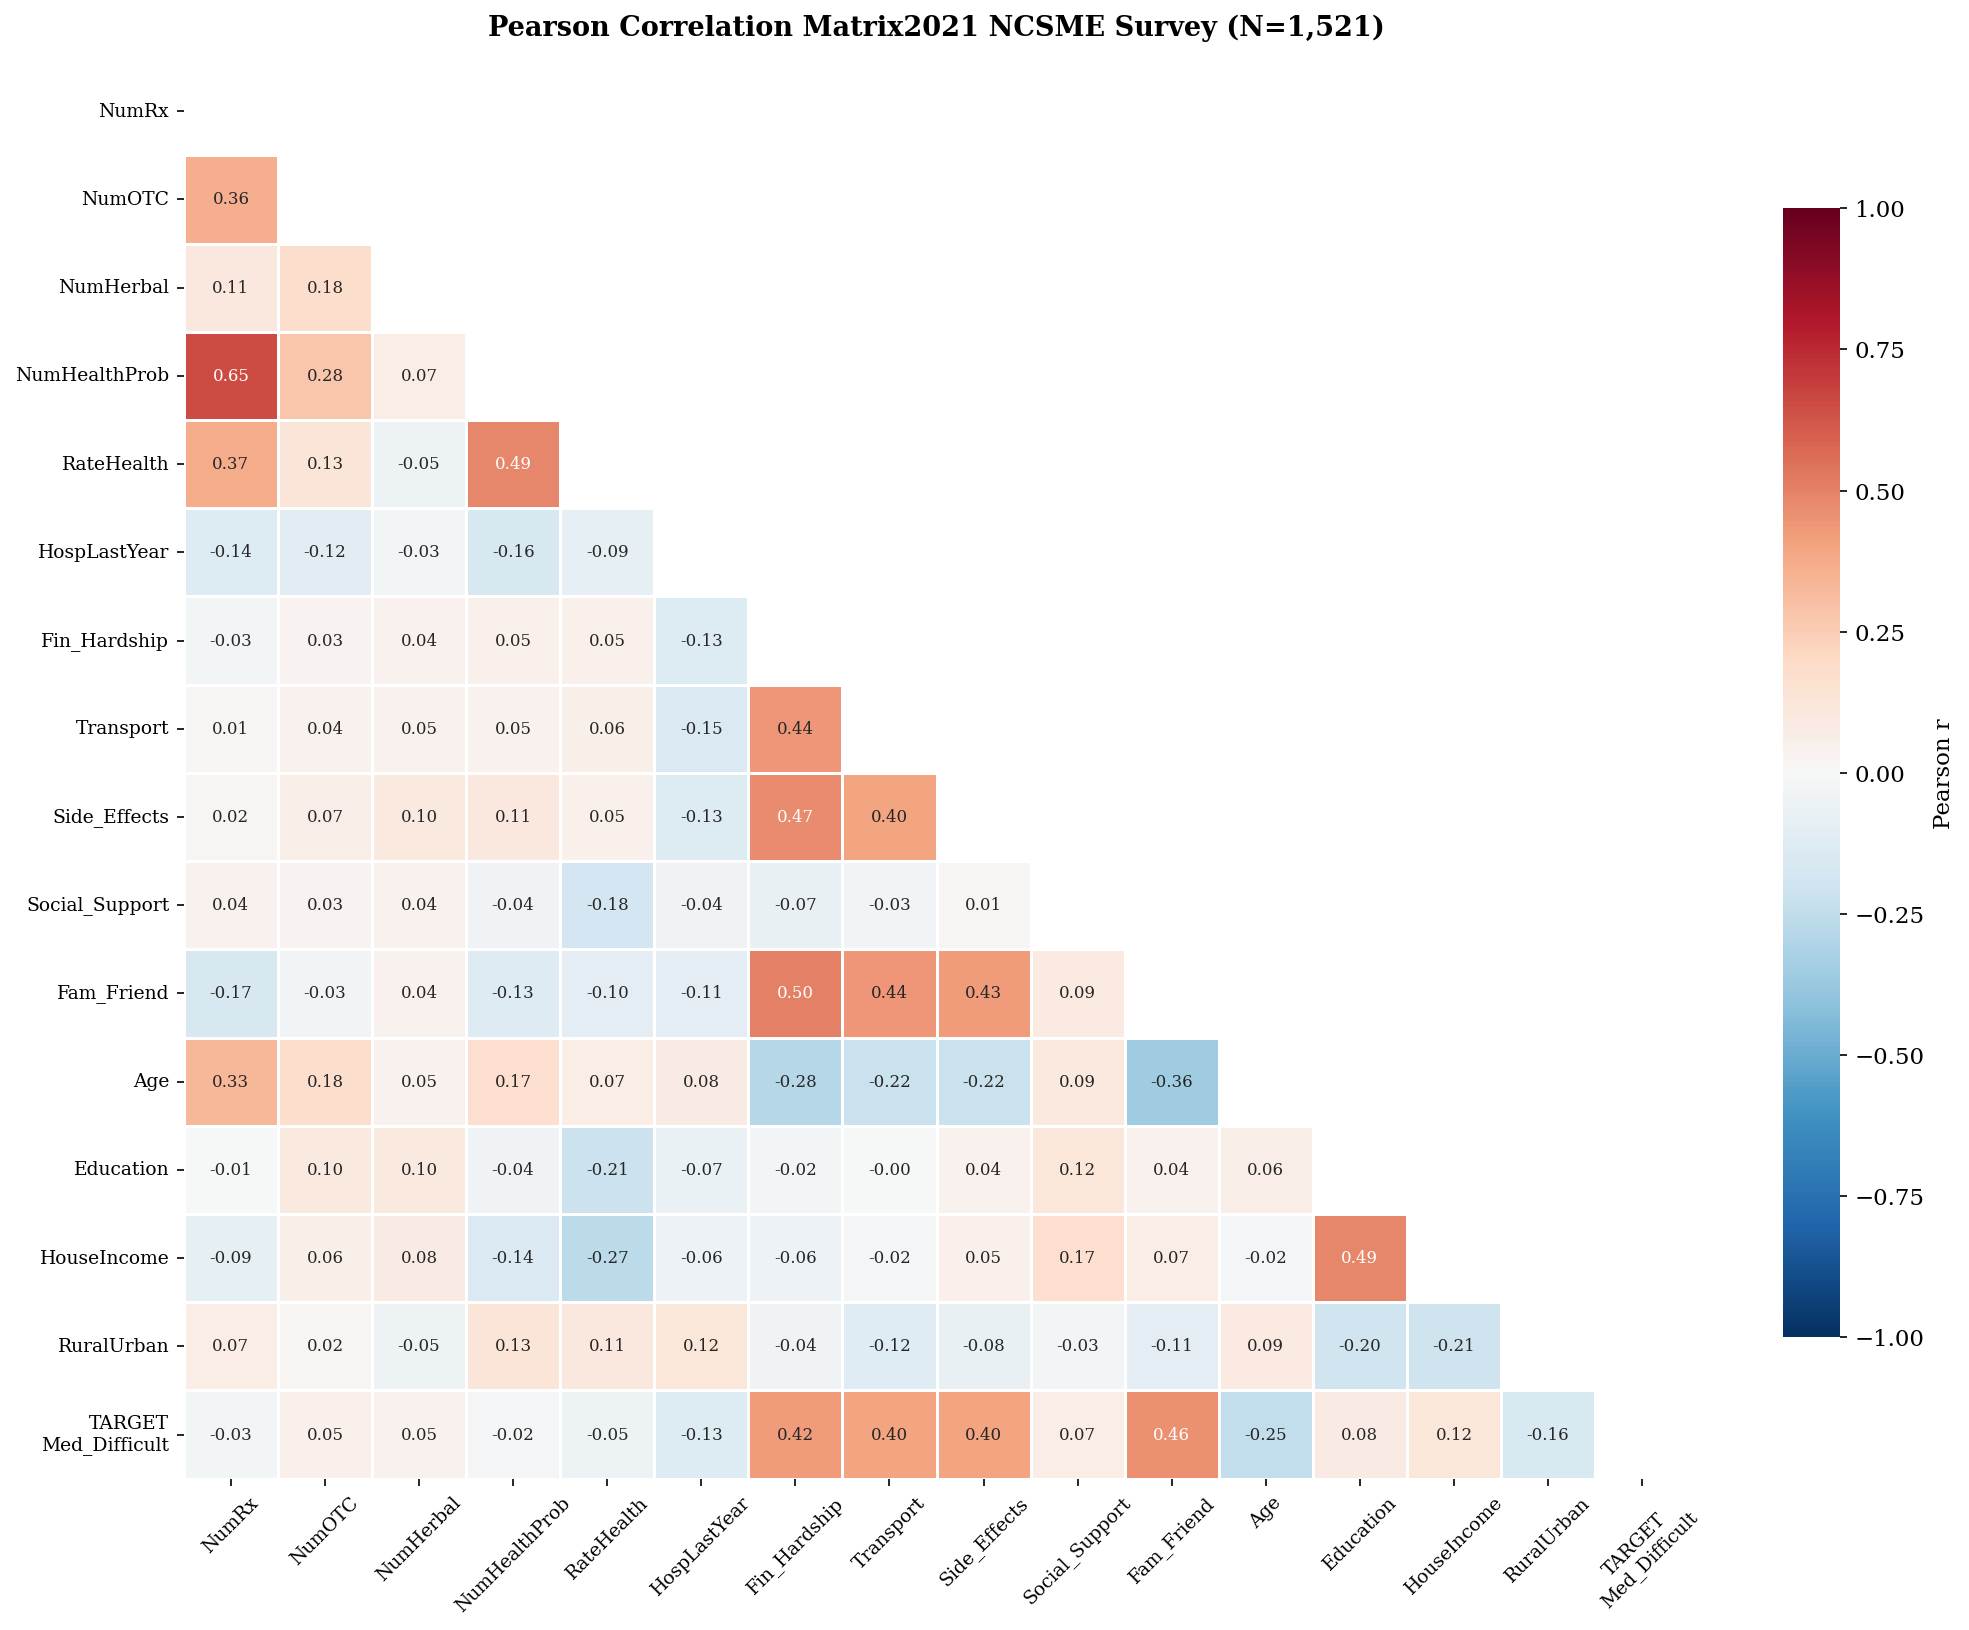

Saved as 'fig3_correlation_heatmap.png'

Inter-predictor correlations |r| ≥ 0.40:
-------------------------------------------------------
  ⚠️  Moderate | NumRx           ↔ NumHealthProb   | r = +0.6492
  ⚠️  Moderate | NumHealthProb   ↔ RateHealth      | r = +0.4897
  ⚠️  Moderate | Fin_Hardship    ↔ Transport       | r = +0.4440
  ⚠️  Moderate | Fin_Hardship    ↔ Side_Effects    | r = +0.4727
  ⚠️  Moderate | Fin_Hardship    ↔ Fam_Friend      | r = +0.5023
  ⚠️  Moderate | Transport       ↔ Fam_Friend      | r = +0.4406
  ⚠️  Moderate | Side_Effects    ↔ Fam_Friend      | r = +0.4267
  ⚠️  Moderate | Education       ↔ HouseIncome     | r = +0.4921

  r > 0.70 = severe  |  r 0.40–0.70 = moderate  |  r < 0.40 = low


In [26]:
# ═════════════════════════════════════════════════════════════════
# CELL 1.8: CORRELATION HEATMAP — MULTICOLLINEARITY CHECK
# ═════════════════════════════════════════════════════════════════
# Before finalizing the feature set we check for MULTICOLLINEARITY
# — when two predictors are so highly correlated that they carry
# essentially the same information, making one redundant.
#
# Thresholds (Pearson r):
#   |r| < 0.40  → Low (no concern)
#   |r| = 0.40–0.70 → Moderate (monitor, acceptable)
#   |r| > 0.70  → High (consider removing one variable)
#
# The heatmap shows all predictors + the target variable.
# ═════════════════════════════════════════════════════════════════

# Short axis labels for readability
HMAP_LABELS = {
    'NumRx':'NumRx', 'NumOTC':'NumOTC', 'NumHerbal':'NumHerbal',
    'NumHealthProb':'NumHealthProb', 'RateHealth':'RateHealth',
    'HospLastYear':'HospLastYear', 'Fin_Hardship':'Fin_Hardship',
    'Transport':'Transport', 'Side_Effects':'Side_Effects',
    'Social_Support':'Social_Support', 'Fam_Friend':'Fam_Friend',
    'Age':'Age', 'Education':'Education', 'HouseIncome':'HouseIncome',
    'RuralUrban':'RuralUrban', 'Med_Difficult_Binary':'TARGET\nMed_Difficult'
}

hmap_vars = ORIG_PREDICTORS + [TARGET]
corr_full = df[hmap_vars].corr()
corr_full.index   = [HMAP_LABELS[c] for c in corr_full.index]
corr_full.columns = [HMAP_LABELS[c] for c in corr_full.columns]

mask = np.triu(np.ones_like(corr_full, dtype=bool))

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(
    corr_full, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    linewidths=0.5, linecolor='white',
    annot_kws={'size': 8}, ax=ax,
    cbar_kws={'shrink': 0.8, 'label': 'Pearson r'}
)
ax.set_title(
    'Pearson Correlation Matrix'
    '2021 NCSME Survey (N=1,521)',
    fontsize=13, fontweight='bold', pad=15
)
ax.tick_params(axis='x', rotation=45, labelsize=9)
ax.tick_params(axis='y', rotation=0,  labelsize=9)
plt.tight_layout()
plt.savefig('fig3_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved as 'fig3_correlation_heatmap.png'")

# Report pairs with |r| >= 0.40
print("\nInter-predictor correlations |r| ≥ 0.40:")
print("-" * 55)
corr_pred = df[ORIG_PREDICTORS].corr()
found_any = False
for i in range(len(ORIG_PREDICTORS)):
    for j in range(i + 1, len(ORIG_PREDICTORS)):
        r = corr_pred.iloc[i, j]
        if abs(r) >= 0.40:
            level = "🔴 High    " if abs(r) >= 0.70 else "⚠️  Moderate"
            print(f"  {level} | {ORIG_PREDICTORS[i]:15} ↔ {ORIG_PREDICTORS[j]:15} | r = {r:+.4f}")
            found_any = True
if not found_any:
    print("  None — no multicollinearity concern detected.")
print("\n  r > 0.70 = severe  |  r 0.40–0.70 = moderate  |  r < 0.40 = low")



---
# PHASE 3 — TRAIN/TEST SPLIT, SCALING & SMOTE

In [27]:
# ═════════════════════════════════════════════════════════════════
# CELL 3.1: TRAIN / TEST SPLIT (80% / 20%)
# ═════════════════════════════════════════════════════════════════
# We split the data BEFORE any scaling or resampling to ensure
# the test set remains completely independent — simulating how
# the model would perform on new, unseen patients in the real world.
#
# Parameters:
#   test_size=0.20   → 20% held out for testing (305 patients)
#   random_state=42  → reproducibility (same split every run)
#   stratify=y       → both splits maintain the original class
#                      ratio prevents accidentally imbalanced splits
# ═════════════════════════════════════════════════════════════════

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.20,
    random_state = 42,
    stratify     = y
)

print(f"\n   Training set : {X_train.shape[0]:,} patients ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"   Test set     : {X_test.shape[0]:,} patients ({X_test.shape[0]/len(X)*100:.0f}%)")
print(f"\n   Class balance — Training set:")
tr_counts = y_train.value_counts()
print(f"     Low Risk  (0): {tr_counts[0]:,} ({tr_counts[0]/len(y_train)*100:.1f}%)")
print(f"     High Risk (1): {tr_counts[1]:,} ({tr_counts[1]/len(y_train)*100:.1f}%)")
print(f"\n   Class balance — Test set:")
te_counts = y_test.value_counts()
print(f"     Low Risk  (0): {te_counts[0]:,} ({te_counts[0]/len(y_test)*100:.1f}%)")
print(f"     High Risk (1): {te_counts[1]:,} ({te_counts[1]/len(y_test)*100:.1f}%)")




   Training set : 1,216 patients (80%)
   Test set     : 305 patients (20%)

   Class balance — Training set:
     Low Risk  (0): 986 (81.1%)
     High Risk (1): 230 (18.9%)

   Class balance — Test set:
     Low Risk  (0): 247 (81.0%)
     High Risk (1): 58 (19.0%)


In [28]:
# ═════════════════════════════════════════════════════════════════
# CELL 3.2: FEATURE SCALING — STANDARDIZATION
# ═════════════════════════════════════════════════════════════════
# Logistic Regression and SVM are sensitive to feature scale.
# Without scaling, large-range variables (Age: 18–89) would
# dominate over narrow-range variables (RuralUrban: 1–2).
#
# StandardScaler transforms each feature so that:
#   New value = (value − mean) / standard deviation
#   Result: mean = 0, std = 1 for every feature
#
# CRITICAL RULE — FIT ONLY ON TRAINING DATA:
#   scaler.fit_transform(X_train) → learns statistics from train only
#   scaler.transform(X_test)      → applies same transform to test
#   This prevents DATA LEAKAGE where test information influences
#   the training process and inflates reported performance.
#
# Note: Random Forest and XGBoost do not require scaling
# (tree splits are scale-invariant)
# ═════════════════════════════════════════════════════════════════

scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit + transform on TRAIN
X_test_scaled  = scaler.transform(X_test)         # transform only on TEST

# Verify scaling
scaled_check = pd.DataFrame(X_train_scaled, columns=PREDICTORS)
print("\nPost-scaling verification (training set):")
print(f"   Mean of all features (should be ≈0): {scaled_check.mean().mean():.6f}")
print(f"   Std  of all features (should be ≈1): {scaled_check.std().mean():.6f}")




Post-scaling verification (training set):
   Mean of all features (should be ≈0): -0.000000
   Std  of all features (should be ≈1): 1.000411


In [29]:
# ═════════════════════════════════════════════════════════════════
# CELL 3.3: SMOTE — SYNTHETIC MINORITY OVERSAMPLING TECHNIQUE
# ═════════════════════════════════════════════════════════════════
# With threshold ≥5, our class split is ~81% Low Risk / ~19% High
# Risk. Without correction, models are biased toward always
# predicting Low Risk — achieving ~81% accuracy by doing nothing.
#
# SMOTE generates SYNTHETIC High Risk patients by interpolating
# between real ones:
#   1. Select a real High Risk patient
#   2. Find its k nearest neighbors (other High Risk patients)
#   3. Draw a new synthetic point along the line connecting them
#   4. Repeat until classes are balanced
#
# This gives the model more High Risk examples to learn from
# without simply duplicating existing records.
#
# SMOTE is applied ONLY to X_train_scaled / y_train.
#     The test set is NEVER resampled — it must reflect the
#     true real-world class distribution for honest evaluation.
# ═════════════════════════════════════════════════════════════════

def apply_smote(X, y, k=5, random_state=42):
    """
    Manual SMOTE implementation using k-nearest neighbors.

    Parameters:
        X            : scaled training feature matrix (numpy array)
        y            : training labels (numpy array or Series)
        k            : number of nearest neighbors
        random_state : seed for reproducibility

    Returns:
        X_resampled  : balanced feature matrix
        y_resampled  : balanced label vector
    """
    rng       = np.random.RandomState(random_state)
    y         = np.array(y)
    X_maj     = X[y == 0]
    X_min     = X[y == 1]
    n_maj     = len(X_maj)
    n_min     = len(X_min)
    n_synth   = n_maj - n_min          # how many synthetic samples needed

    # Fit KNN on minority class
    nn = NearestNeighbors(n_neighbors=k + 1)
    nn.fit(X_min)
    _, indices = nn.kneighbors(X_min)  # indices[i] = k+1 nearest neighbors of point i

    synthetic = []
    for _ in range(n_synth):
        idx          = rng.randint(0, n_min)                   # random minority point
        neighbor_idx = indices[idx, rng.randint(1, k + 1)]     # random neighbor
        gap          = rng.uniform(0, 1)                       # interpolation weight
        new_point    = X_min[idx] + gap * (X_min[neighbor_idx] - X_min[idx])
        synthetic.append(new_point)

    X_synth     = np.array(synthetic)
    y_synth     = np.ones(n_synth, dtype=int)

    X_resampled = np.vstack([X, X_synth])
    y_resampled = np.concatenate([y, y_synth])
    return X_resampled, y_resampled


print("Applying SMOTE to training set...")
print(f"\nBefore SMOTE:")
print(f"   Low Risk  (0): {(y_train==0).sum():,} samples")
print(f"   High Risk (1): {(y_train==1).sum():,} samples")
print(f"   Imbalance ratio: {(y_train==0).sum()/(y_train==1).sum():.2f}:1")

X_train_smote, y_train_smote = apply_smote(
    X_train_scaled, y_train.values, k=5, random_state=42
)

unique, smote_counts = np.unique(y_train_smote, return_counts=True)
print(f"\nAfter SMOTE:")
for cls, cnt in zip(unique, smote_counts):
    lbl = "Low Risk  (0)" if cls == 0 else "High Risk (1)"
    print(f"   {lbl}: {cnt:,} samples ({cnt/len(y_train_smote)*100:.1f}%)")
print(f"\n   Total training samples: {len(y_train_smote):,}")
print(f"   Synthetic samples added: {len(y_train_smote) - len(y_train):,}")




Applying SMOTE to training set...

Before SMOTE:
   Low Risk  (0): 986 samples
   High Risk (1): 230 samples
   Imbalance ratio: 4.29:1

After SMOTE:
   Low Risk  (0): 986 samples (50.0%)
   High Risk (1): 986 samples (50.0%)

   Total training samples: 1,972
   Synthetic samples added: 756


---
# PHASE 4 — MODEL BUILDING & HYPERPARAMETER TUNING

In [30]:
# ═════════════════════════════════════════════════════════════════
# CELL 4.1: MODEL 1 — LOGISTIC REGRESSION (Baseline)
# ═════════════════════════════════════════════════════════════════
# Logistic Regression is our BASELINE model. It estimates the log-odds of being
# High Risk as a linear combination of predictor variables:
#
#   log(p/1-p) = β₀ + β₁X₁ + β₂X₂ + ... + βₙXₙ
#
# The sigmoid function converts this to a probability (0–1).
# If probability ≥ 0.5 → predicted High Risk (1)
# ═════════════════════════════════════════════════════════════════

from sklearn.model_selection import GridSearchCV

print("Training Logistic Regression with GridSearchCV...")

lr_param_grid = {
    'C'      : [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver' : ['saga']
}

lr_grid = GridSearchCV(
    estimator  = LogisticRegression(max_iter=3000, random_state=42),
    param_grid = lr_param_grid,
    scoring    = 'recall',
    cv         = 5,
    n_jobs     = -1,
    verbose    = 0
)
lr_grid.fit(X_train_smote, y_train_smote)

lr_best        = lr_grid.best_estimator_
lr_preds       = lr_best.predict(X_test_scaled)
lr_proba       = lr_best.predict_proba(X_test_scaled)[:, 1]

print(f"Best Parameters : {lr_grid.best_params_}")
print(f"   Best CV Recall  : {lr_grid.best_score_:.4f}")



Training Logistic Regression with GridSearchCV...
Best Parameters : {'C': 0.01, 'penalty': 'l1', 'solver': 'saga'}
   Best CV Recall  : 0.8103


In [31]:
# ═════════════════════════════════════════════════════════════════
# CELL 4.2: MODEL 2 — RANDOM FOREST (Ensemble Tree-Based)
# ═════════════════════════════════════════════════════════════════
# Random Forest builds n_estimators decision trees, each trained
# on a random bootstrap sample of the data using a random subset
# of features at each split. Predictions are made by majority vote.
#
# Advantages:
#   → Handles non-linear relationships naturally
#   → Robust to outliers and irrelevant features
#   → Provides reliable feature importance scores
#   → Less prone to overfitting than a single decision tree
#
# GridSearchCV tunes:
#   n_estimators     → number of trees
#   max_depth        → depth limit per tree
#   min_samples_split → minimum samples to split a node
#   max_features     → features considered per split
# ═════════════════════════════════════════════════════════════════

print("Training Random Forest with GridSearchCV...")

rf_param_grid = {
    'n_estimators'    : [100, 200, 300],
    'max_depth'       : [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'max_features'    : ['sqrt', 'log2']
}

rf_grid = GridSearchCV(
    estimator  = RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid = rf_param_grid,
    scoring    = 'recall',
    cv         = 5,
    n_jobs     = -1,
    verbose    = 0
)
rf_grid.fit(X_train_smote, y_train_smote)

rf_best  = rf_grid.best_estimator_
rf_preds = rf_best.predict(X_test_scaled)
rf_proba = rf_best.predict_proba(X_test_scaled)[:, 1]

print(f"Best Parameters : {rf_grid.best_params_}")
print(f"   Best CV Recall  : {rf_grid.best_score_:.4f}")



Training Random Forest with GridSearchCV...
Best Parameters : {'max_depth': 15, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 100}
   Best CV Recall  : 0.9128


In [32]:
# ═════════════════════════════════════════════════════════════════
# CELL 4.3: MODEL 3 — SUPPORT VECTOR MACHINE
# ═════════════════════════════════════════════════════════════════
# SVM finds the optimal hyperplane that separates the two classes
# with the maximum margin. The RBF kernel maps data into a higher-
# dimensional space to capture non-linear boundaries.
#
# GridSearchCV tunes:
#   C      → Regularization (low=wide margin, high=narrow margin)
#   gamma  → Influence radius of each training point
#   kernel → rbf (non-linear) or linear (straight boundary)
# ═════════════════════════════════════════════════════════════════

print("Training Support Vector Machine with GridSearchCV...")

svm_param_grid = {
    'C'     : [0.1, 1, 10, 100],
    'gamma' : ['scale', 'auto', 0.01, 0.1],
    'kernel': ['rbf', 'linear']
}

svm_grid = GridSearchCV(
    estimator  = SVC(probability=True, random_state=42),
    param_grid = svm_param_grid,
    scoring    = 'recall',
    cv         = 5,
    n_jobs     = -1,
    verbose    = 0
)
svm_grid.fit(X_train_smote, y_train_smote)

svm_best  = svm_grid.best_estimator_
svm_preds = svm_best.predict(X_test_scaled)
svm_proba = svm_best.predict_proba(X_test_scaled)[:, 1]

print(f"Best Parameters : {svm_grid.best_params_}")
print(f"   Best CV Recall  : {svm_grid.best_score_:.4f}")



Training Support Vector Machine with GridSearchCV...
Best Parameters : {'C': 100, 'gamma': 0.1, 'kernel': 'rbf'}
   Best CV Recall  : 0.9787


In [33]:
# ═════════════════════════════════════════════════════════════════
# CELL 4.4: MODEL 4 — XGBOOST (Gradient Boosting)
# ═════════════════════════════════════════════════════════════════
# XGBoost (Extreme Gradient Boosting) is a powerful ensemble method
# that builds trees SEQUENTIALLY — each new tree corrects the
# errors made by all previous trees (boosting). This contrasts
# with Random Forest where trees are built independently.
#
# XGBoost is widely considered known for tabular clinical data
#
# Key parameters tuned:
#   n_estimators  → number of boosting rounds
#   max_depth     → depth of each tree (shallower = more regularized)
#   learning_rate → step size shrinkage (lower = more conservative)
#   subsample     → fraction of training samples per tree
#   colsample_bytree → fraction of features per tree
#
# scale_pos_weight = n_negative/n_positive handles class imbalance
# within XGBoost itself
# ═════════════════════════════════════════════════════════════════

print("Training XGBoost with GridSearchCV...")

# scale_pos_weight for any residual imbalance after SMOTE
scale_pw = int((y_train_smote == 0).sum() / (y_train_smote == 1).sum())

xgb_param_grid = {
    'n_estimators' : [100, 200, 300],
    'max_depth'    : [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample'    : [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

xgb_grid = GridSearchCV(
    estimator  = XGBClassifier(
        scale_pos_weight = scale_pw,
        random_state     = 42,
        eval_metric      = 'logloss',
        verbosity        = 0
    ),
    param_grid = xgb_param_grid,
    scoring    = 'recall',
    cv         = 5,
    n_jobs     = -1,
    verbose    = 0
)
xgb_grid.fit(X_train_smote, y_train_smote)

xgb_best  = xgb_grid.best_estimator_
xgb_preds = xgb_best.predict(X_test_scaled)
xgb_proba = xgb_best.predict_proba(X_test_scaled)[:, 1]

print(f" Best Parameters : {xgb_grid.best_params_}")
print(f"   Best CV Recall  : {xgb_grid.best_score_:.4f}")



Training XGBoost with GridSearchCV...
 Best Parameters : {'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 100, 'subsample': 0.8}
   Best CV Recall  : 0.9067


---
# PHASE 5 —  EVALUATION

In [34]:
# ═════════════════════════════════════════════════════════════════
# CELL 5.1: PERFORMANCE METRICS — ALL FOUR MODELS
# ═════════════════════════════════════════════════════════════════
# We evaluate each model on the  test set using:
#
#   Accuracy  → % of all patients correctly classified
#               Formula: (TP + TN) / Total
#
#   Precision → Of patients PREDICTED high-risk, how many truly are?
#               Formula: TP / (TP + FP)
#
#   Recall    → Of ACTUAL high-risk patients, how many did we identify?
#               Formula: TP / (TP + FN)
#               PRIORITY METRIC — missing a high-risk patient
#               (False Negative) risks hospitalization and harm
#
#   F1-Score  → Harmonic mean of Precision and Recall
#               Best when both Precision and Recall matter
#
#   ROC-AUC   → Overall discrimination ability across all thresholds
#               0.5 = random  |  1.0 = perfect  |  ≥0.80 = excellent
# ═════════════════════════════════════════════════════════════════

all_models = {
    'Logistic Regression'    : (lr_preds, lr_proba),
    'Random Forest'          : (rf_preds, rf_proba),
    'Support Vector Machine' : (svm_preds, svm_proba),
    'XGBoost'                : (xgb_preds, xgb_proba)
}

results = {}
print("=" * 70)
print("  PERFORMANCE METRICS — ALL FOUR MODELS (Test Set)")
print("=" * 70)

for name, (preds, proba) in all_models.items():
    acc  = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds, zero_division=0)
    rec  = recall_score(y_test, preds, zero_division=0)
    f1   = f1_score(y_test, preds, zero_division=0)
    auc_score = roc_auc_score(y_test, proba)
    results[name] = {
        'Accuracy' : acc, 'Precision': prec,
        'Recall'   : rec, 'F1-Score' : f1,
        'ROC-AUC'  : auc_score
    }
    print(f"\n   {name}")
    print(f"     Accuracy  : {acc:.4f}  ({acc*100:.1f}%)")
    print(f"     Precision : {prec:.4f}")
    print(f"     Recall    : {rec:.4f}  ← (minimizing missed high-risk patients)")
    print(f"     F1-Score  : {f1:.4f}")
    print(f"     ROC-AUC   : {auc_score:.4f}")

print("\n" + "=" * 70)
print("  TABLE 2 — MODEL PERFORMANCE COMPARISON")
print("=" * 70)
results_df = pd.DataFrame(results).T.round(4)
print(results_df)
results_df.to_csv('table2_model_performance.csv')
print("\n Table 2 saved as 'table2_model_performance.csv'")



  PERFORMANCE METRICS — ALL FOUR MODELS (Test Set)

   Logistic Regression
     Accuracy  : 0.8033  (80.3%)
     Precision : 0.4896
     Recall    : 0.8103  ← (minimizing missed high-risk patients)
     F1-Score  : 0.6104
     ROC-AUC   : 0.8674

   Random Forest
     Accuracy  : 0.8590  (85.9%)
     Precision : 0.6596
     Recall    : 0.5345  ← (minimizing missed high-risk patients)
     F1-Score  : 0.5905
     ROC-AUC   : 0.8546

   Support Vector Machine
     Accuracy  : 0.7967  (79.7%)
     Precision : 0.4677
     Recall    : 0.5000  ← (minimizing missed high-risk patients)
     F1-Score  : 0.4833
     ROC-AUC   : 0.7667

   XGBoost
     Accuracy  : 0.8361  (83.6%)
     Precision : 0.5714
     Recall    : 0.5517  ← (minimizing missed high-risk patients)
     F1-Score  : 0.5614
     ROC-AUC   : 0.8450

  TABLE 2 — MODEL PERFORMANCE COMPARISON
                        Accuracy  Precision  Recall  F1-Score  ROC-AUC
Logistic Regression       0.8033     0.4896  0.8103    0.6104   0.8674


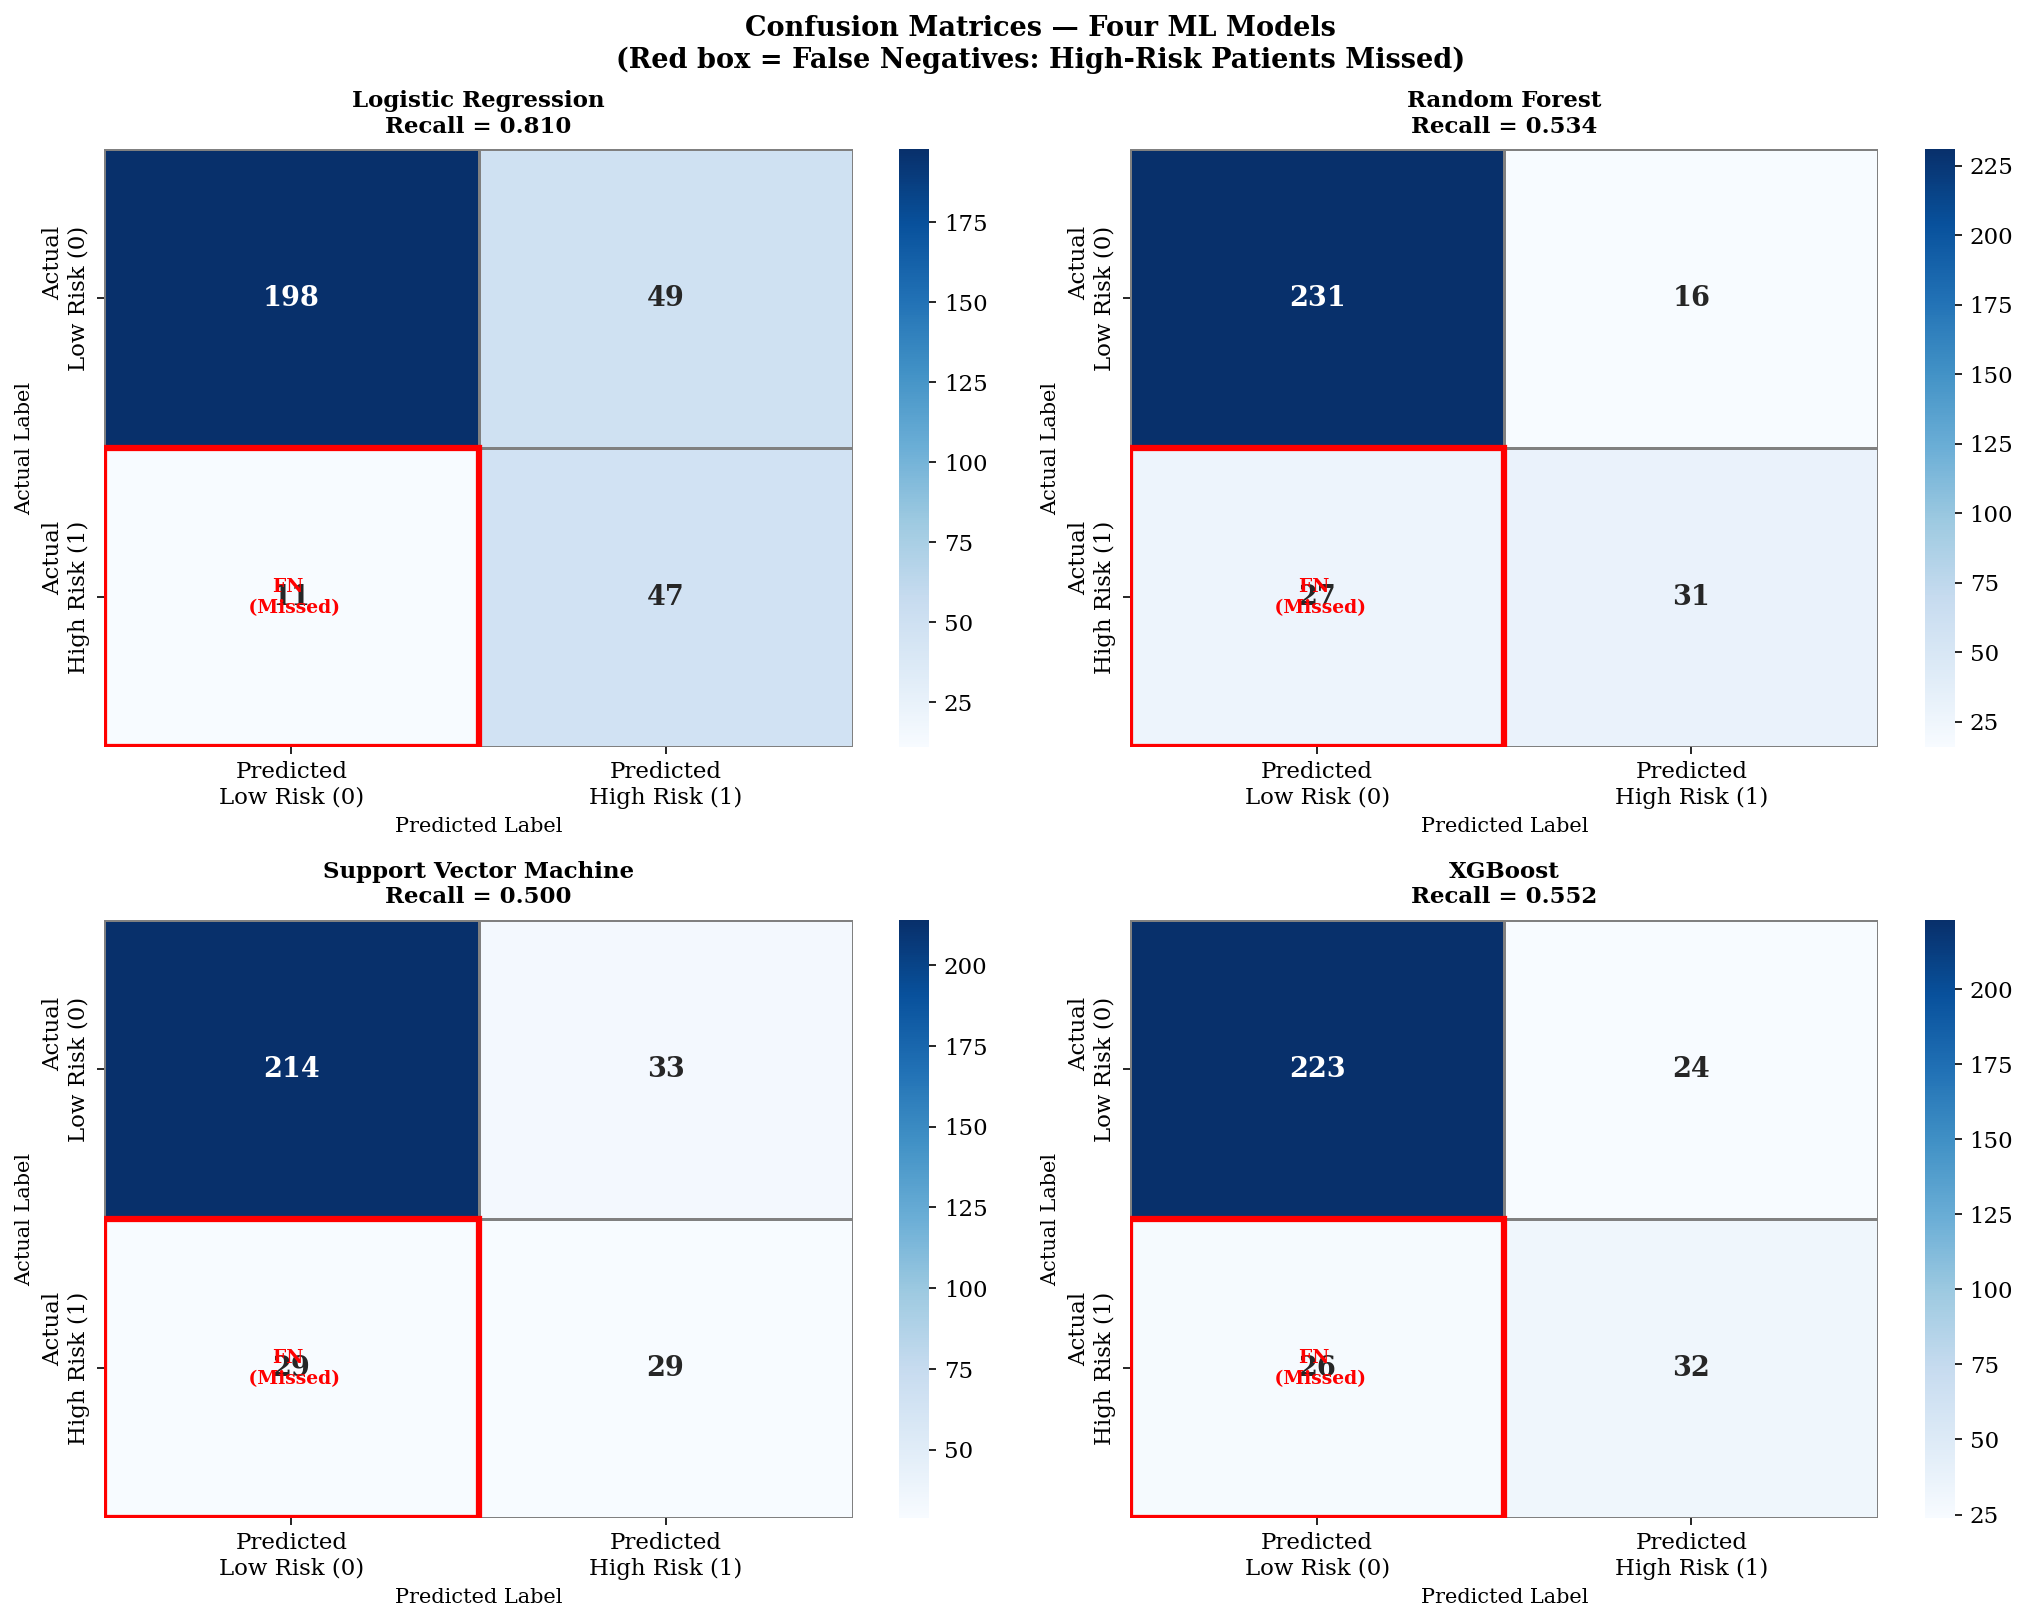

Saved as 'fig4_confusion_matrices.png'


In [35]:
# ═════════════════════════════════════════════════════════════════
# CELL 5.2: CONFUSION MATRICES — ALL FOUR MODELS
# ═════════════════════════════════════════════════════════════════
# Confusion matrix breakdown:
#
#   True Negative  (TN): Low-risk correctly identified
#   False Positive (FP): Low-risk wrongly flagged
#   False Negative (FN): HIGH-RISK MISSED
#   True Positive  (TP): High-risk correctly identified
#
# The red rectangle highlights the FN cell in each matrix —
# this is what we most want to minimize in clinical practice.
# ═════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
axes = axes.flatten()

for ax, (name, (preds, _)) in zip(axes, all_models.items()):
    cm = confusion_matrix(y_test, preds)
    tn, fp, fn, tp = cm.ravel()
    rec = tp / (tp + fn) if (tp + fn) > 0 else 0

    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues', ax=ax,
        xticklabels=['Predicted\nLow Risk (0)', 'Predicted\nHigh Risk (1)'],
        yticklabels=['Actual\nLow Risk (0)', 'Actual\nHigh Risk (1)'],
        linewidths=0.5, linecolor='gray',
        annot_kws={'size': 13, 'weight': 'bold'}
    )
    ax.set_title(f"{name}\nRecall = {rec:.3f}",
                 fontsize=11, fontweight='bold', pad=8)
    ax.set_ylabel('Actual Label', fontsize=10)
    ax.set_xlabel('Predicted Label', fontsize=10)
    # Highlight FN cell (bottom-left) in red
    ax.add_patch(plt.Rectangle((0, 1), 1, 1, fill=False,
                                edgecolor='red', lw=3))
    ax.text(0.5, 1.5, 'FN \n (Missed)', ha='center', va='center',
            fontsize=9, color='red', fontweight='bold')

fig.suptitle(
    'Confusion Matrices — Four ML Models\n'
    '(Red box = False Negatives: High-Risk Patients Missed)',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig('fig4_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved as 'fig4_confusion_matrices.png'")



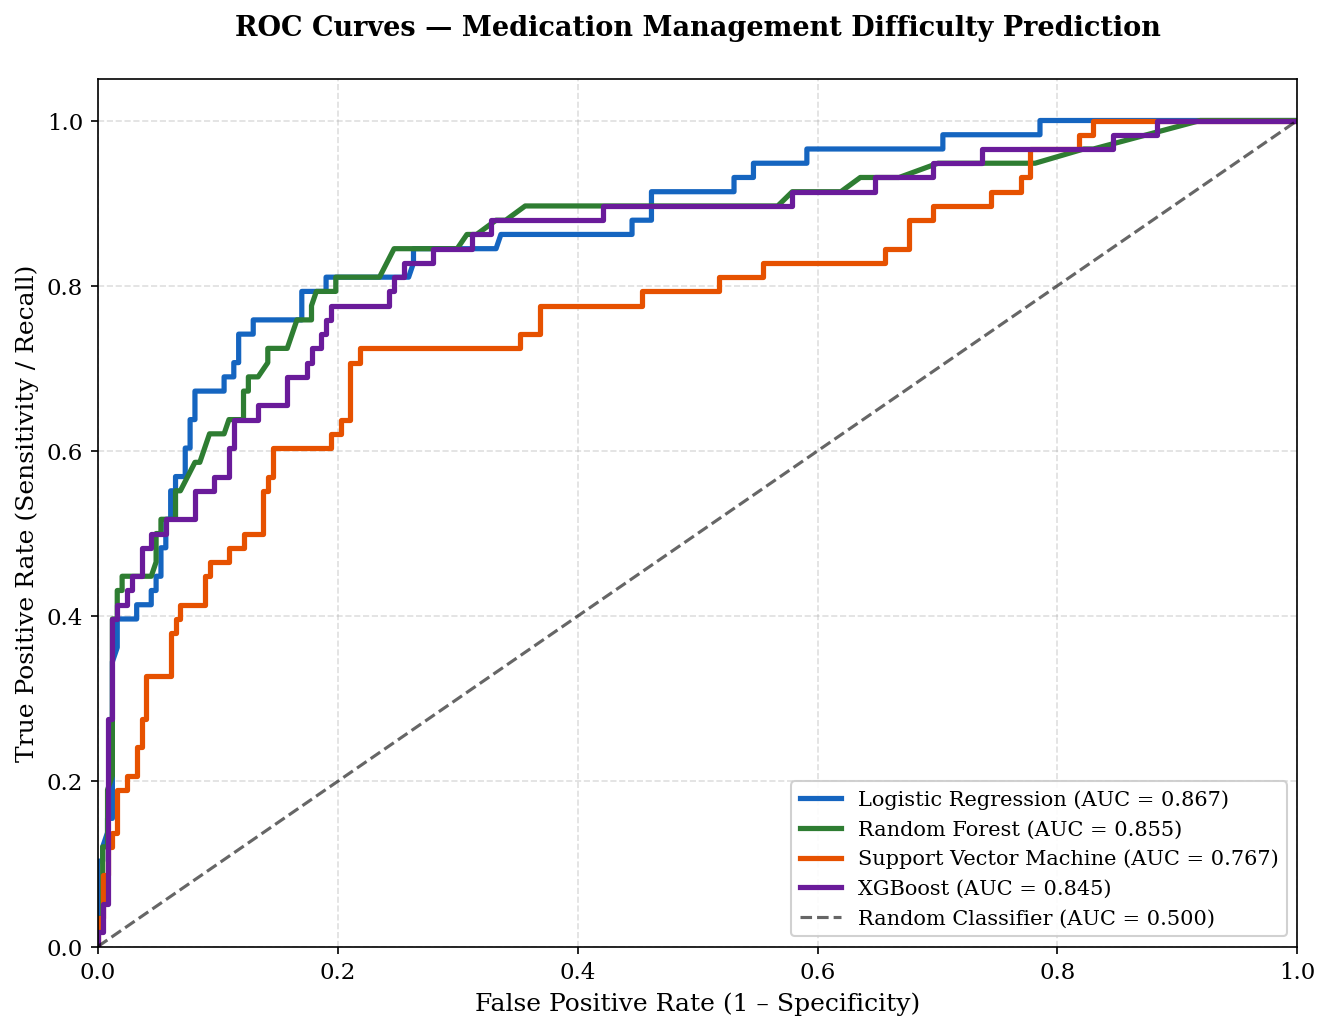

Saved as 'fig5_roc_auc_curves.png'


In [36]:
# ═════════════════════════════════════════════════════════════════
# CELL 5.3: ROC-AUC CURVES — ALL FOUR MODELS
# ═════════════════════════════════════════════════════════════════
# The ROC (Receiver Operating Characteristic) curve plots:
#   X-axis: False Positive Rate = FP / (FP + TN)
#   Y-axis: True Positive Rate (Recall) = TP / (TP + FN)
#
# Each point on the curve represents a different classification
# threshold.
#   AUC = 0.50 → random classifier
#   AUC = 0.70 → acceptable
#   AUC = 0.80 → excellent
#   AUC = 1.00 → perfect classifier
#
# ═════════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(9, 7))

model_colors = {
    'Logistic Regression'    : '#1565C0',
    'Random Forest'          : '#2E7D32',
    'Support Vector Machine' : '#E65100',
    'XGBoost'                : '#6A1B9A'
}

for name, (preds, proba) in all_models.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc_val     = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, lw=2.5, color=model_colors[name],
            label=f"{name} (AUC = {auc_val:.3f})")

# Diagonal reference line (random classifier)
ax.plot([0, 1], [0, 1], 'k--', lw=1.5, alpha=0.6, label='Random Classifier (AUC = 0.500)')

ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate (1 – Specificity)', fontsize=12)
ax.set_ylabel('True Positive Rate (Sensitivity / Recall)', fontsize=12)
ax.set_title('ROC Curves — Medication Management Difficulty Prediction\n', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=10, framealpha=0.9)
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('fig5_roc_auc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved as 'fig5_roc_auc_curves.png'")



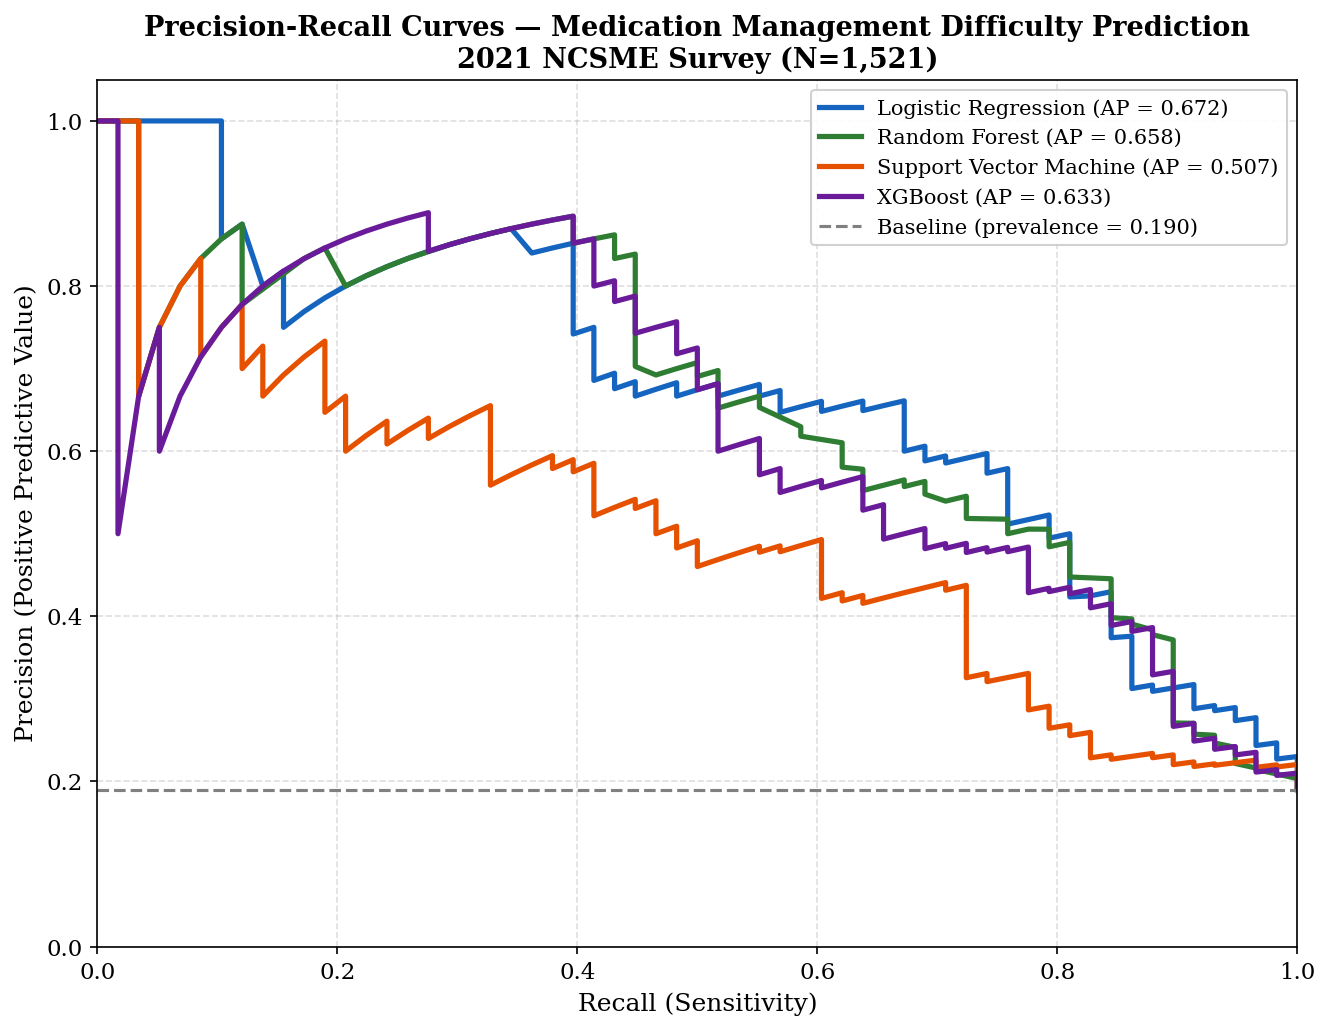

Saved as 'fig6_precision_recall_curves.png'


In [37]:
# ═════════════════════════════════════════════════════════════════
# CELL 5.4: PRECISION-RECALL CURVES — ALL FOUR MODELS
# ═════════════════════════════════════════════════════════════════
# Precision-Recall curves are MORE INFORMATIVE than ROC curves
# for imbalanced datasets. They show the trade-off between:
#   Precision (avoiding false alarms) vs Recall (catching all cases)
#
# The dashed horizontal line shows the baseline precision —
# equal to the prevalence of High Risk in the test set.
# Any curve above this line represents genuine predictive skill.
#
# Average Precision (AP) summarizes the area under the curve.
# ═════════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(9, 7))

baseline_precision = y_test.mean()   # prevalence of positive class

for name, (preds, proba) in all_models.items():
    prec_curve, rec_curve, _ = precision_recall_curve(y_test, proba)
    ap = average_precision_score(y_test, proba)
    ax.plot(rec_curve, prec_curve, lw=2.5, color=model_colors[name],
            label=f"{name} (AP = {ap:.3f})")

ax.axhline(y=baseline_precision, color='gray', linestyle='--', lw=1.5,
           label=f'Baseline (prevalence = {baseline_precision:.3f})')

ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('Recall (Sensitivity)', fontsize=12)
ax.set_ylabel('Precision (Positive Predictive Value)', fontsize=12)
ax.set_title('Precision-Recall Curves — Medication Management Difficulty Prediction\n'
             '2021 NCSME Survey (N=1,521)', fontsize=13, fontweight='bold')
ax.legend(loc='upper right', fontsize=10, framealpha=0.9)
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('fig6_precision_recall_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved as 'fig6_precision_recall_curves.png'")



In [38]:
# ═════════════════════════════════════════════════════════════════
# CELL 5.5: 10-FOLD CROSS-VALIDATION
# ═════════════════════════════════════════════════════════════════
# A single 80/20 split may produce results dependent on which
# patients happened to fall in the test set.
#
# 10-fold cross-validation provides a more RELIABLE estimate by:
#   1. Splitting training data into 10 equal folds
#   2. Training on 9 folds and evaluating on the 1 remaining fold
#   3. Rotating through all 10 combinations
#   4. Reporting Mean ± Standard Deviation across 10 evaluations
#
# This shows both average performance AND stability.
# A small standard deviation means results are consistent
#
# Note: CV is performed on the SMOTE training data only.
# ═════════════════════════════════════════════════════════════════

print("Running 10-Fold Cross-Validation on all four models...")

cv_models = {
    'Logistic Regression'    : lr_best,
    'Random Forest'          : rf_best,
    'Support Vector Machine' : svm_best,
    'XGBoost'                : xgb_best
}

cv_results = {}
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

for name, model in cv_models.items():
    scores = {}
    for metric in ['accuracy', 'precision', 'recall', 'f1']:
        cv_scores = cross_val_score(
            model, X_train_smote, y_train_smote,
            cv=skf, scoring=metric, n_jobs=-1
        )
        scores[metric] = cv_scores
    cv_results[name] = scores
    print(f"   {name} — CV complete")

# Display results
print("\n" + "=" * 70)
print("  TABLE 3 — 10-FOLD CROSS-VALIDATION RESULTS (Mean ± Std Dev)")
print("=" * 70)

cv_table_rows = []
for name, scores in cv_results.items():
    row = {'Model': name}
    for metric, cv_scores in scores.items():
        row[metric.capitalize()] = f"{cv_scores.mean():.4f} ± {cv_scores.std():.4f}"
    cv_table_rows.append(row)

cv_table = pd.DataFrame(cv_table_rows).set_index('Model')
print(cv_table.to_string())
cv_table.to_csv('table3_cross_validation.csv')
print("\n Table 3 saved as 'table3_cross_validation.csv'")



Running 10-Fold Cross-Validation on all four models...
   Logistic Regression — CV complete
   Random Forest — CV complete
   Support Vector Machine — CV complete
   XGBoost — CV complete

  TABLE 3 — 10-FOLD CROSS-VALIDATION RESULTS (Mean ± Std Dev)
                               Accuracy        Precision           Recall               F1
Model                                                                                     
Logistic Regression     0.7946 ± 0.0293  0.7882 ± 0.0371  0.8084 ± 0.0352  0.7975 ± 0.0279
Random Forest           0.9295 ± 0.0137  0.9420 ± 0.0190  0.9158 ± 0.0232  0.9285 ± 0.0144
Support Vector Machine  0.9396 ± 0.0135  0.9122 ± 0.0228  0.9736 ± 0.0103  0.9417 ± 0.0127
XGBoost                 0.9184 ± 0.0209  0.9310 ± 0.0174  0.9036 ± 0.0305  0.9169 ± 0.0220

 Table 3 saved as 'table3_cross_validation.csv'


In [39]:
# ═════════════════════════════════════════════════════════════════
# CELL 5.6: McNEMAR'S TEST — STATISTICAL SIGNIFICANCE BETWEEN MODELS
# ═════════════════════════════════════════════════════════════════
# McNemar's test determines whether the DIFFERENCE in performance
# between two models is STATISTICALLY SIGNIFICANT or could be
# due to chance.
#
# It works by comparing the cases where:
#   - Model A is correct but Model B is wrong (b)
#   - Model B is correct but Model A is wrong (c)
#
# If b and c are very different, one model is genuinely better.
#
# H₀ (null hypothesis): The two models perform equally well
# If p < 0.05 → reject H₀ → one model is significantly better
#
# We compare every pair of models.
# ═════════════════════════════════════════════════════════════════

from statsmodels.stats.contingency_tables import mcnemar

print("McNemar's Test — Pairwise Model Comparison")
print("=" * 60)
print("H₀: The two models perform equally well")
print("p < 0.05 → statistically significant difference\n")

model_preds = {
    'Logistic Regression'    : lr_preds,
    'Random Forest'          : rf_preds,
    'Support Vector Machine' : svm_preds,
    'XGBoost'                : xgb_preds
}

y_test_arr   = np.array(y_test)
model_names  = list(model_preds.keys())
mcnemar_rows = []

for i in range(len(model_names)):
    for j in range(i + 1, len(model_names)):
        name_a = model_names[i]
        name_b = model_names[j]
        preds_a = np.array(model_preds[name_a])
        preds_b = np.array(model_preds[name_b])

        # Build 2x2 contingency table
        # b = A correct, B wrong | c = A wrong, B correct
        correct_a = (preds_a == y_test_arr)
        correct_b = (preds_b == y_test_arr)
        b = np.sum(correct_a & ~correct_b)   # A right, B wrong
        c = np.sum(~correct_a & correct_b)   # A wrong, B right
        table = [[np.sum(correct_a & correct_b), b],
                 [c, np.sum(~correct_a & ~correct_b)]]

        result = mcnemar(table, exact=True)
        sig    = ('***' if result.pvalue < 0.001 else
                  ('**'  if result.pvalue < 0.01  else
                  ('*'   if result.pvalue < 0.05  else 'ns')))

        mcnemar_rows.append({
            'Model A'  : name_a,
            'Model B'  : name_b,
            'b (A✓B✗)': b,
            'c (A✗B✓)': c,
            'p-value'  : f"{result.pvalue:.4f}",
            'Sig.'     : sig
        })
        print(f"  {name_a[:4]} vs {name_b[:4]} | b={b}, c={c} | p={result.pvalue:.4f} {sig}")

mcnemar_df = pd.DataFrame(mcnemar_rows)
mcnemar_df.to_csv('table4_mcnemar_test.csv', index=False)
print("\nSignificance: *** p<0.001  ** p<0.01  * p<0.05  ns=not significant")



McNemar's Test — Pairwise Model Comparison
H₀: The two models perform equally well
p < 0.05 → statistically significant difference

  Logi vs Rand | b=18, c=35 | p=0.0270 *
  Logi vs Supp | b=38, c=36 | p=0.9076 ns
  Logi vs XGBo | b=21, c=31 | p=0.2116 ns
  Rand vs Supp | b=32, c=13 | p=0.0066 **
  Rand vs XGBo | b=13, c=6 | p=0.1671 ns
  Supp vs XGBo | b=17, c=29 | p=0.1038 ns

Significance: *** p<0.001  ** p<0.01  * p<0.05  ns=not significant


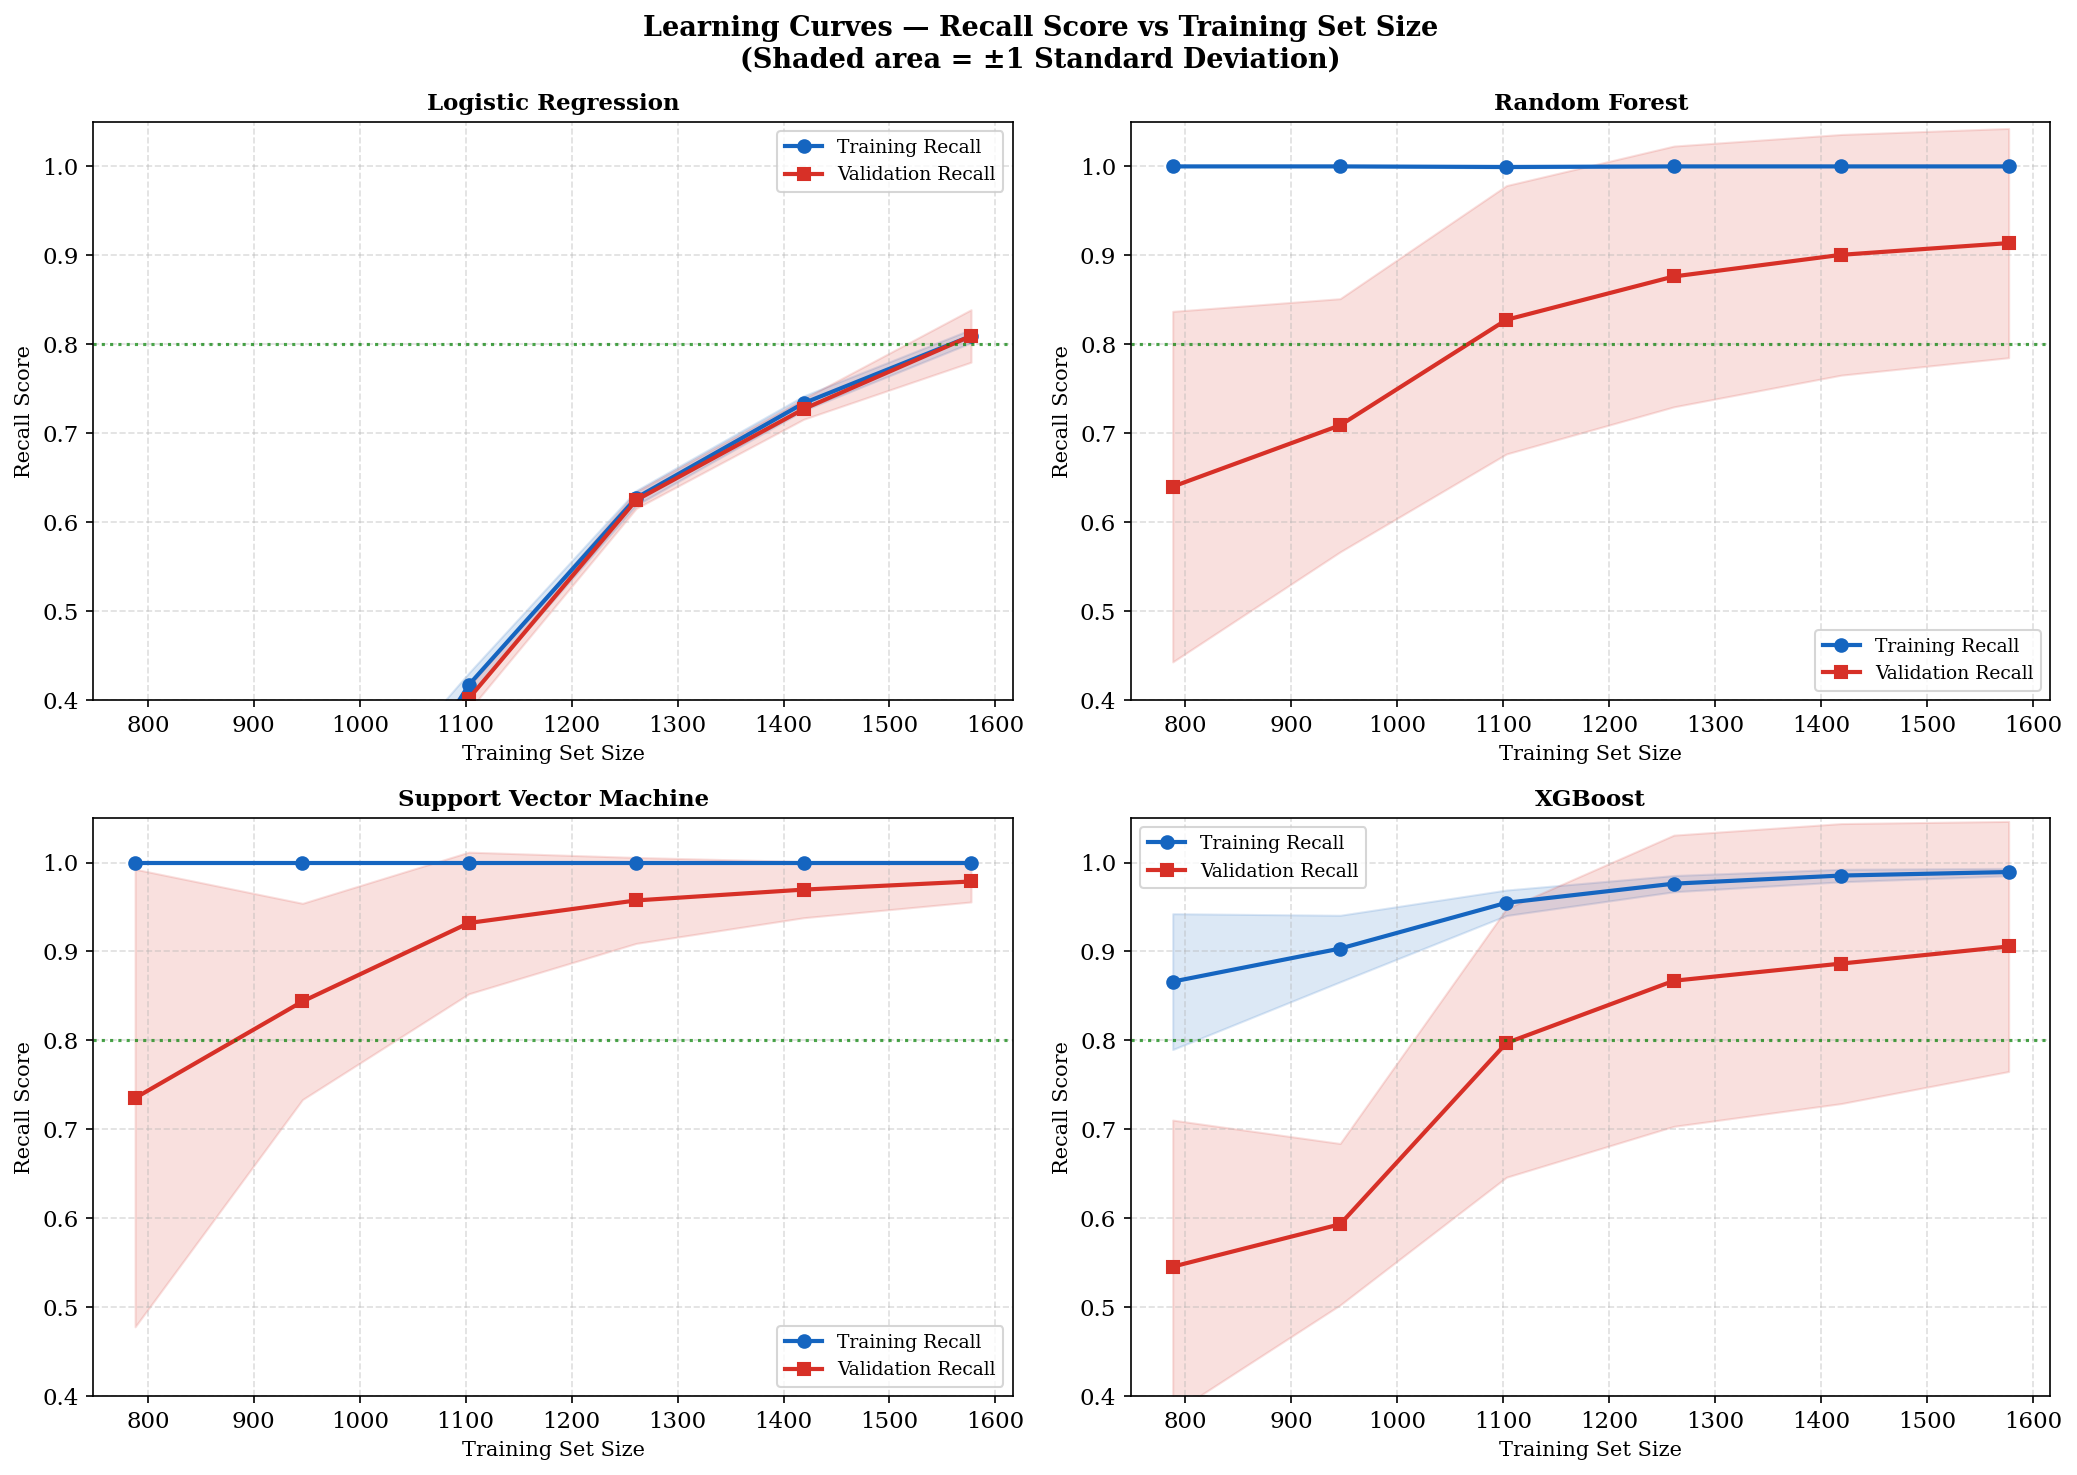

Saved as 'fig7_learning_curves.png'


In [40]:
# ═════════════════════════════════════════════════════════════════
# CELL 5.7: LEARNING CURVES
# ═════════════════════════════════════════════════════════════════
# Learning curves show how model performance changes as MORE
# training data is added. They diagnose:
#
#   HIGH BIAS (underfitting):
#     Both training and validation scores are low and plateau early
#     → Model is too simple and needs more features
#
#   HIGH VARIANCE (overfitting):
#     Training score is high but validation score is much lower
#     → Large gap between curves, needs more data or regularization
#
#   GOOD FIT:
#     Both curves converge at a high value
#     → Model has learned well from available data
# ═════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

train_sizes = np.linspace(0.1, 1.0, 10)

for ax, (name, model) in zip(axes, cv_models.items()):
    train_sz, train_sc, val_sc = learning_curve(
        model, X_train_smote, y_train_smote,
        train_sizes = train_sizes,
        cv          = 5,
        scoring     = 'recall',
        n_jobs      = -1
    )
    train_mean = train_sc.mean(axis=1)
    train_std  = train_sc.std(axis=1)
    val_mean   = val_sc.mean(axis=1)
    val_std    = val_sc.std(axis=1)

    ax.plot(train_sz, train_mean, 'o-', color='#1565C0',
            lw=2, label='Training Recall')
    ax.fill_between(train_sz, train_mean - train_std,
                    train_mean + train_std, alpha=0.15, color='#1565C0')
    ax.plot(train_sz, val_mean, 's-', color='#d73027',
            lw=2, label='Validation Recall')
    ax.fill_between(train_sz, val_mean - val_std,
                    val_mean + val_std, alpha=0.15, color='#d73027')

    ax.set_title(name, fontsize=11, fontweight='bold')
    ax.set_xlabel('Training Set Size', fontsize=10)
    ax.set_ylabel('Recall Score', fontsize=10)
    ax.set_ylim([0.4, 1.05])
    ax.legend(fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.axhline(y=0.80, color='green', linestyle=':', lw=1.5,
               alpha=0.7, label='80% target')

fig.suptitle('Learning Curves — Recall Score vs Training Set Size\n'
             '(Shaded area = ±1 Standard Deviation)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig7_learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved as 'fig7_learning_curves.png'")



---
# PHASE 6 — MODEL INTERPRETABILITY

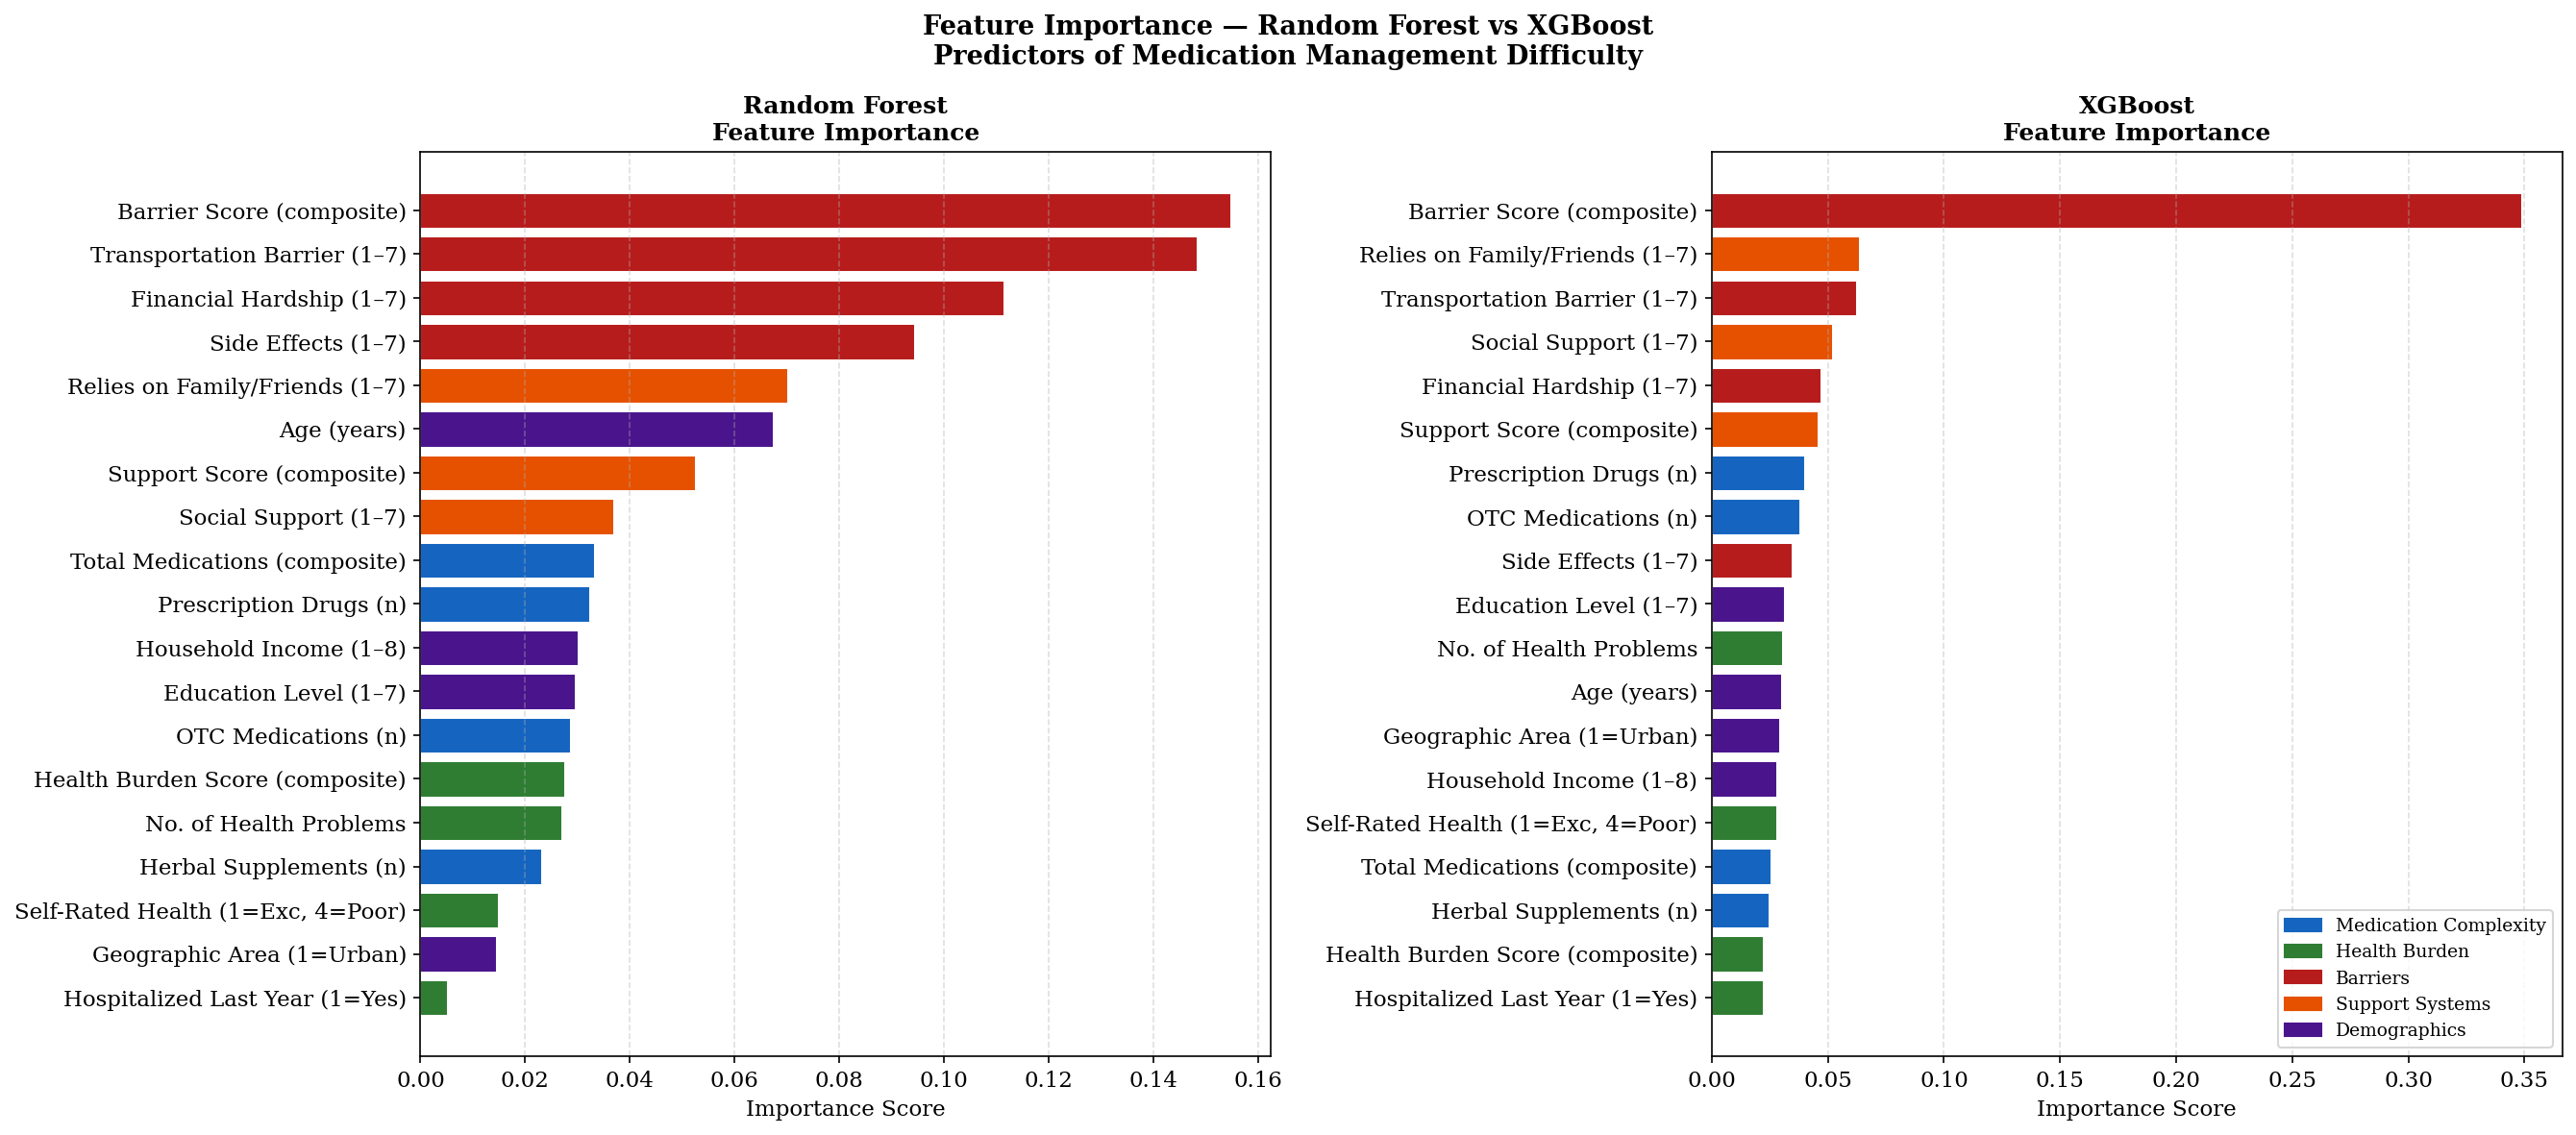

Saved as 'fig8_feature_importance.png'


In [41]:
# ═════════════════════════════════════════════════════════════════
# CELL 6.1: FEATURE IMPORTANCE — RANDOM FOREST & XGBOOST
# ═════════════════════════════════════════════════════════════════
# Tree-based models provide feature importance scores that measure
# how much each predictor contributed to reducing classification
# error across all trees.
#
# Random Forest: Mean Decrease in Impurity (Gini importance)
#   → Measures average reduction in node impurity per feature
#
# XGBoost: Weight-based importance
#   → Measures how often a feature is used to split nodes
#
# These scores directly answer: "Which patient characteristics
# most strongly predict medication management difficulties?"
# ═════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Category color coding for clinical interpretation
cat_colors = {
    'NumRx':'#1565C0', 'NumOTC':'#1565C0', 'NumHerbal':'#1565C0',
    'NumHealthProb':'#2E7D32','RateHealth':'#2E7D32','HospLastYear':'#2E7D32',
    'Fin_Hardship':'#B71C1C','Transport':'#B71C1C','Side_Effects':'#B71C1C',
    'Social_Support':'#E65100','Fam_Friend':'#E65100',
    'Age':'#4A148C','Education':'#4A148C','HouseIncome':'#4A148C','RuralUrban':'#4A148C',
    'Total_Meds':'#1565C0','Barrier_Score':'#B71C1C',
    'Support_Score':'#E65100','Health_Score':'#2E7D32'
}

for ax, (model_name, model) in zip(axes, [('Random Forest', rf_best),
                                            ('XGBoost', xgb_best)]):
    imp_df = pd.DataFrame({
        'Feature'   : PREDICTORS,
        'Importance': model.feature_importances_
    }).sort_values('Importance', ascending=True)

    colors = [cat_colors[f] for f in imp_df['Feature']]
    labels = [LABEL_MAP[f] for f in imp_df['Feature']]

    imp_df['Label'] = labels
    ax.barh(imp_df['Label'], imp_df['Importance'],
            color=colors, edgecolor='white', linewidth=0.5)
    ax.set_xlabel('Importance Score', fontsize=11)
    ax.set_title(f'{model_name}\nFeature Importance', fontsize=12, fontweight='bold')
    ax.grid(axis='x', linestyle='--', alpha=0.4)


from matplotlib.patches import Patch
legend_elements = [
    Patch(color='#1565C0', label='Medication Complexity'),
    Patch(color='#2E7D32', label='Health Burden'),
    Patch(color='#B71C1C', label='Barriers'),
    Patch(color='#E65100', label='Support Systems'),
    Patch(color='#4A148C', label='Demographics'),
]
axes[1].legend(handles=legend_elements, loc='lower right', fontsize=9)

fig.suptitle('Feature Importance — Random Forest vs XGBoost\n'
             'Predictors of Medication Management Difficulty',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig8_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved as 'fig8_feature_importance.png'")



Model A training matrix shape: (1216, 15)
Model B training matrix shape: (1216, 8)
Target vector shape          : (1216,)

Fitting Model A — Original 15 variables...

 TABLE 5A — Logistic Regression: Original 15 Variables
                         Variable  Coefficient  Odds Ratio  95% CI Lower  95% CI Upper  p-value Sig.
     Transportation Barrier (1–7)       0.6276      1.8731        1.5095        2.3242   0.0000  ***
         Financial Hardship (1–7)       0.5794      1.7850        1.4268        2.2332   0.0000  ***
               Side Effects (1–7)       0.5105      1.6662        1.3471        2.0608   0.0000  ***
   Relies on Family/Friends (1–7)       0.4865      1.6266        1.3064        2.0253   0.0000  ***
           Prescription Drugs (n)       0.2712      1.3116        1.0225        1.6824   0.0327    *
           Household Income (1–8)       0.2258      1.2534        1.0112        1.5535   0.0392    *
              OTC Medications (n)       0.1126      1.1192        0.919

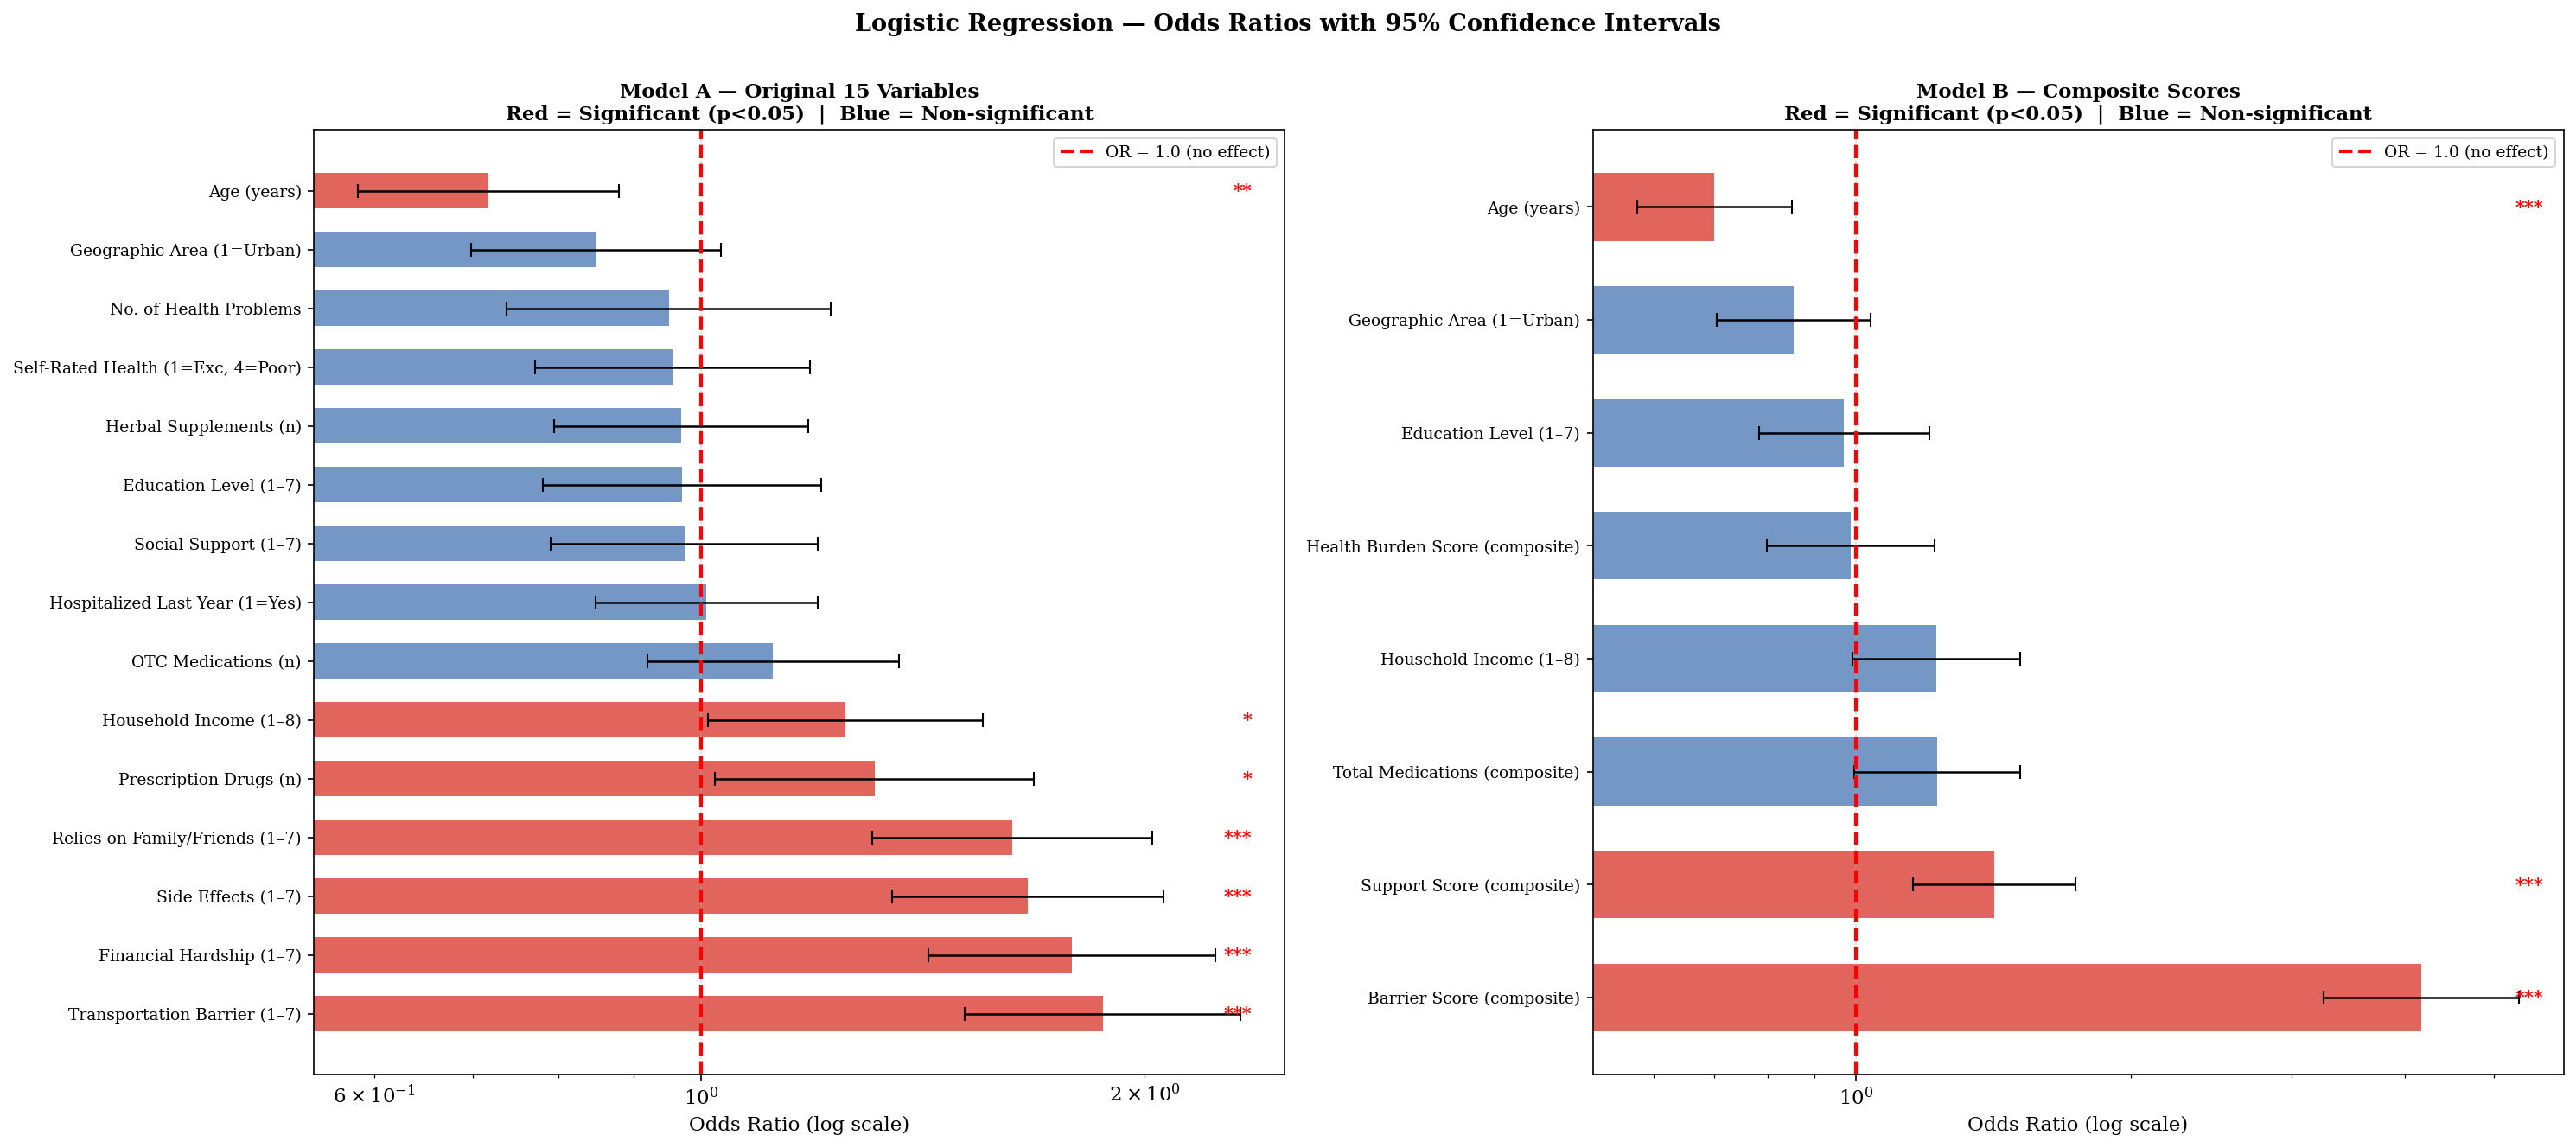


 Forest plots saved as 'fig9_odds_ratios.png'


In [42]:
# ═════════════════════════════════════════════════════════════════
# CELL 6.2 (FINAL): ODDS RATIOS
# ═════════════════════════════════════════════════════════════════
# We run TWO separate logistic regression models to avoid
# multicollinearity between original variables and their composites:
#
#   Model A → Original 15 variables only
#
#   Model B → 4 Composite scores + demographics
#
# Both models use the ORIGINAL training data (not SMOTE) because:
#   - SMOTE data violates MLE statistical assumptions
#   - Statistical inference requires real observed data only
#   - SMOTE is only for training predictive models
#
# We also rebuild X_train fresh for each model using only
# its relevant columns to avoid shape mismatch errors.
# ═════════════════════════════════════════════════════════════════

import statsmodels.api as sm

# Model A: Original 15 variables
ORIG_15 = [
    'NumRx', 'NumOTC', 'NumHerbal',
    'NumHealthProb', 'RateHealth', 'HospLastYear',
    'Fin_Hardship', 'Transport', 'Side_Effects',
    'Social_Support', 'Fam_Friend',
    'Age', 'Education', 'HouseIncome', 'RuralUrban'
]

# Model B: Composite scores + demographics
COMPOSITES = [
    'Total_Meds', 'Barrier_Score', 'Support_Score', 'Health_Score',
    'Age', 'Education', 'HouseIncome', 'RuralUrban'
]

# ── Rebuild training matrices  for each model ────────────────
# We use X_train.index to select the correct rows from df
# and scale each model's columns independently
# This avoids the shape mismatch error

scaler_A = StandardScaler()
scaler_B = StandardScaler()

# Model A training matrix — original 15 variables only
X_train_orig = pd.DataFrame(
    scaler_A.fit_transform(df[ORIG_15].iloc[X_train.index]),
    columns = ORIG_15
)

# Model B training matrix — composites + demographics only
X_train_comp = pd.DataFrame(
    scaler_B.fit_transform(df[COMPOSITES].iloc[X_train.index]),
    columns = COMPOSITES
)

# Target vector — original training labels
y_orig = y_train.values

print(f"Model A training matrix shape: {X_train_orig.shape}")
print(f"Model B training matrix shape: {X_train_comp.shape}")
print(f"Target vector shape          : {y_orig.shape}")


# ── Function: fit Logit and return odds ratio table ────────

def fit_logit_or(X_df, y, pred_list, label_map):
    """
    Fits statsmodels Logit on provided data and returns a clean
    odds ratio DataFrame with coefficients, OR, 95% CI, p-values.

    Parameters:
        X_df      : DataFrame of scaled predictor variables
        y         : numpy array of binary target labels
        pred_list : list of column names to include
        label_map : dictionary mapping variable names to labels

    Returns:
        or_df     : DataFrame with odds ratio results
        result    : fitted statsmodels Logit result object
    """
    # Add intercept constant
    X_const = sm.add_constant(X_df[pred_list])

    # Fit using BFGS optimizer for logistic regression
    result = sm.Logit(y, X_const).fit(
        method  = 'bfgs',
        maxiter = 1000,
        disp    = False
    )

    # Extract parameters
    params  = result.params[pred_list]
    pvalues = result.pvalues[pred_list]

    # Extract confidence intervals
    try:
        conf     = result.conf_int().loc[pred_list]
        ci_lower = np.exp(conf[0].values)
        ci_upper = np.exp(conf[1].values)
    except Exception:
        ci_lower = np.full(len(pred_list), np.nan)
        ci_upper = np.full(len(pred_list), np.nan)

    # Build results table
    or_df = pd.DataFrame({
        'Variable'     : [label_map.get(p, p) for p in pred_list],
        'Coefficient'  : params.values.round(4),
        'Odds Ratio'   : np.exp(params.values).round(4),
        '95% CI Lower' : ci_lower.round(4),
        '95% CI Upper' : ci_upper.round(4),
        'p-value'      : pvalues.values.round(4),
        'Sig.'         : ['***' if p < 0.001 else
                          ('**'  if p < 0.01  else
                          ('*'   if p < 0.05  else 'ns'))
                          for p in pvalues.values]
    }).sort_values('Odds Ratio', ascending=False).reset_index(drop=True)

    return or_df, result


# ── Fit Model A: Original 15 variables ───────────────────────────
print("\nFitting Model A — Original 15 variables...")
or_df_A, result_A = fit_logit_or(
    X_train_orig, y_orig, ORIG_15, LABEL_MAP
)

print("\n TABLE 5A — Logistic Regression: Original 15 Variables")
print("=" * 95)
print(or_df_A.to_string(index=False))
print("\nNote: *** p<0.001  ** p<0.01  * p<0.05  ns = not significant")
print("      OR > 1 = increases risk  |  OR < 1 = decreases risk")
or_df_A.to_csv('table5A_odds_ratios_original.csv', index=False)
print("\n Saved as 'table5A_odds_ratios_original.csv'")


# ── Fit Model B: Composite scores ────────────────────────────────
print("\n\nFitting Model B — Composite scores + demographics...")
or_df_B, result_B = fit_logit_or(
    X_train_comp, y_orig, COMPOSITES, LABEL_MAP
)

print("\nTABLE 5B — Logistic Regression: Composite Scores")
print("=" * 95)
print(or_df_B.to_string(index=False))
print("\nNote: *** p<0.001  ** p<0.01  * p<0.05  ns = not significant")
print("      OR > 1 = increases risk  |  OR < 1 = decreases risk")
or_df_B.to_csv('table5B_odds_ratios_composites.csv', index=False)
print("\n Saved as 'table5B_odds_ratios_composites.csv'")


# ── Model Fit Statistics ──────────────────────────────────────────
print("\n" + "=" * 60)
print("  MODEL FIT STATISTICS")
print("=" * 60)
print(f"\n  Model A (Original Variables)")
print(f"    Pseudo R² (McFadden) : {result_A.prsquared:.4f}")
print(f"    Log-Likelihood       : {result_A.llf:.2f}")
print(f"    AIC                  : {result_A.aic:.2f}")
print(f"    BIC                  : {result_A.bic:.2f}")
print(f"    LLR p-value          : {result_A.llr_pvalue:.4e}")

print(f"\n  Model B (Composite Scores)")
print(f"    Pseudo R² (McFadden) : {result_B.prsquared:.4f}")
print(f"    Log-Likelihood       : {result_B.llf:.2f}")
print(f"    AIC                  : {result_B.aic:.2f}")
print(f"    BIC                  : {result_B.bic:.2f}")
print(f"    LLR p-value          : {result_B.llr_pvalue:.4e}")


# ── Forest Plots  ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(20, 9))

for ax, (or_df_plot, title) in zip(axes, [
    (or_df_A, 'Model A — Original 15 Variables'),
    (or_df_B, 'Model B — Composite Scores')
]):
    sig_mask  = or_df_plot['p-value'] < 0.05
    colors_or = ['#d73027' if s else '#4575b4' for s in sig_mask]
    y_pos     = range(len(or_df_plot))

    # Cap CI upper at OR × 5 to prevent huge error bars
    # from any remaining separation issues
    ci_lower_plot = or_df_plot['95% CI Lower'].fillna(
        or_df_plot['Odds Ratio']
    )
    ci_upper_plot = np.minimum(
        or_df_plot['95% CI Upper'].fillna(or_df_plot['Odds Ratio']),
        or_df_plot['Odds Ratio'] * 5
    )

    ax.barh(
        y_pos,
        or_df_plot['Odds Ratio'],
        xerr = [
            or_df_plot['Odds Ratio'] - ci_lower_plot,
            ci_upper_plot - or_df_plot['Odds Ratio']
        ],
        height    = 0.6,
        color     = colors_or,
        alpha     = 0.75,
        error_kw  = dict(ecolor='black', capsize=4, linewidth=1.2)
    )

    # Reference line at OR = 1.0
    ax.axvline(x=1.0, color='red', linestyle='--',
               lw=2, label='OR = 1.0 (no effect)')

    # Axis labels and formatting
    ax.set_yticks(y_pos)
    ax.set_yticklabels(or_df_plot['Variable'], fontsize=9)
    ax.set_xlabel('Odds Ratio (log scale)', fontsize=11)
    ax.set_xscale('log')
    ax.set_title(
        f'{title}\nRed = Significant (p<0.05)  |  Blue = Non-significant',
        fontsize=11, fontweight='bold'
    )
    ax.legend(fontsize=9)
    ax.grid(axis='x', linestyle='--', alpha=0.4)


    for i, (_, row) in enumerate(or_df_plot.iterrows()):
        if row['Sig.'] != 'ns':
            ax.text(
                ax.get_xlim()[1] * 0.95, i,
                row['Sig.'],
                va='center', ha='right',
                fontsize=10, color='red', fontweight='bold'
            )

fig.suptitle(
    'Logistic Regression — Odds Ratios with 95% Confidence Intervals\n',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig('fig9_odds_ratios.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n Forest plots saved as 'fig9_odds_ratios.png'")

Computing permutation importance for all models...
(This may take a few minutes)

  Logistic Regression — done
  Random Forest — done
  Support Vector Machine — done
  XGBoost — done


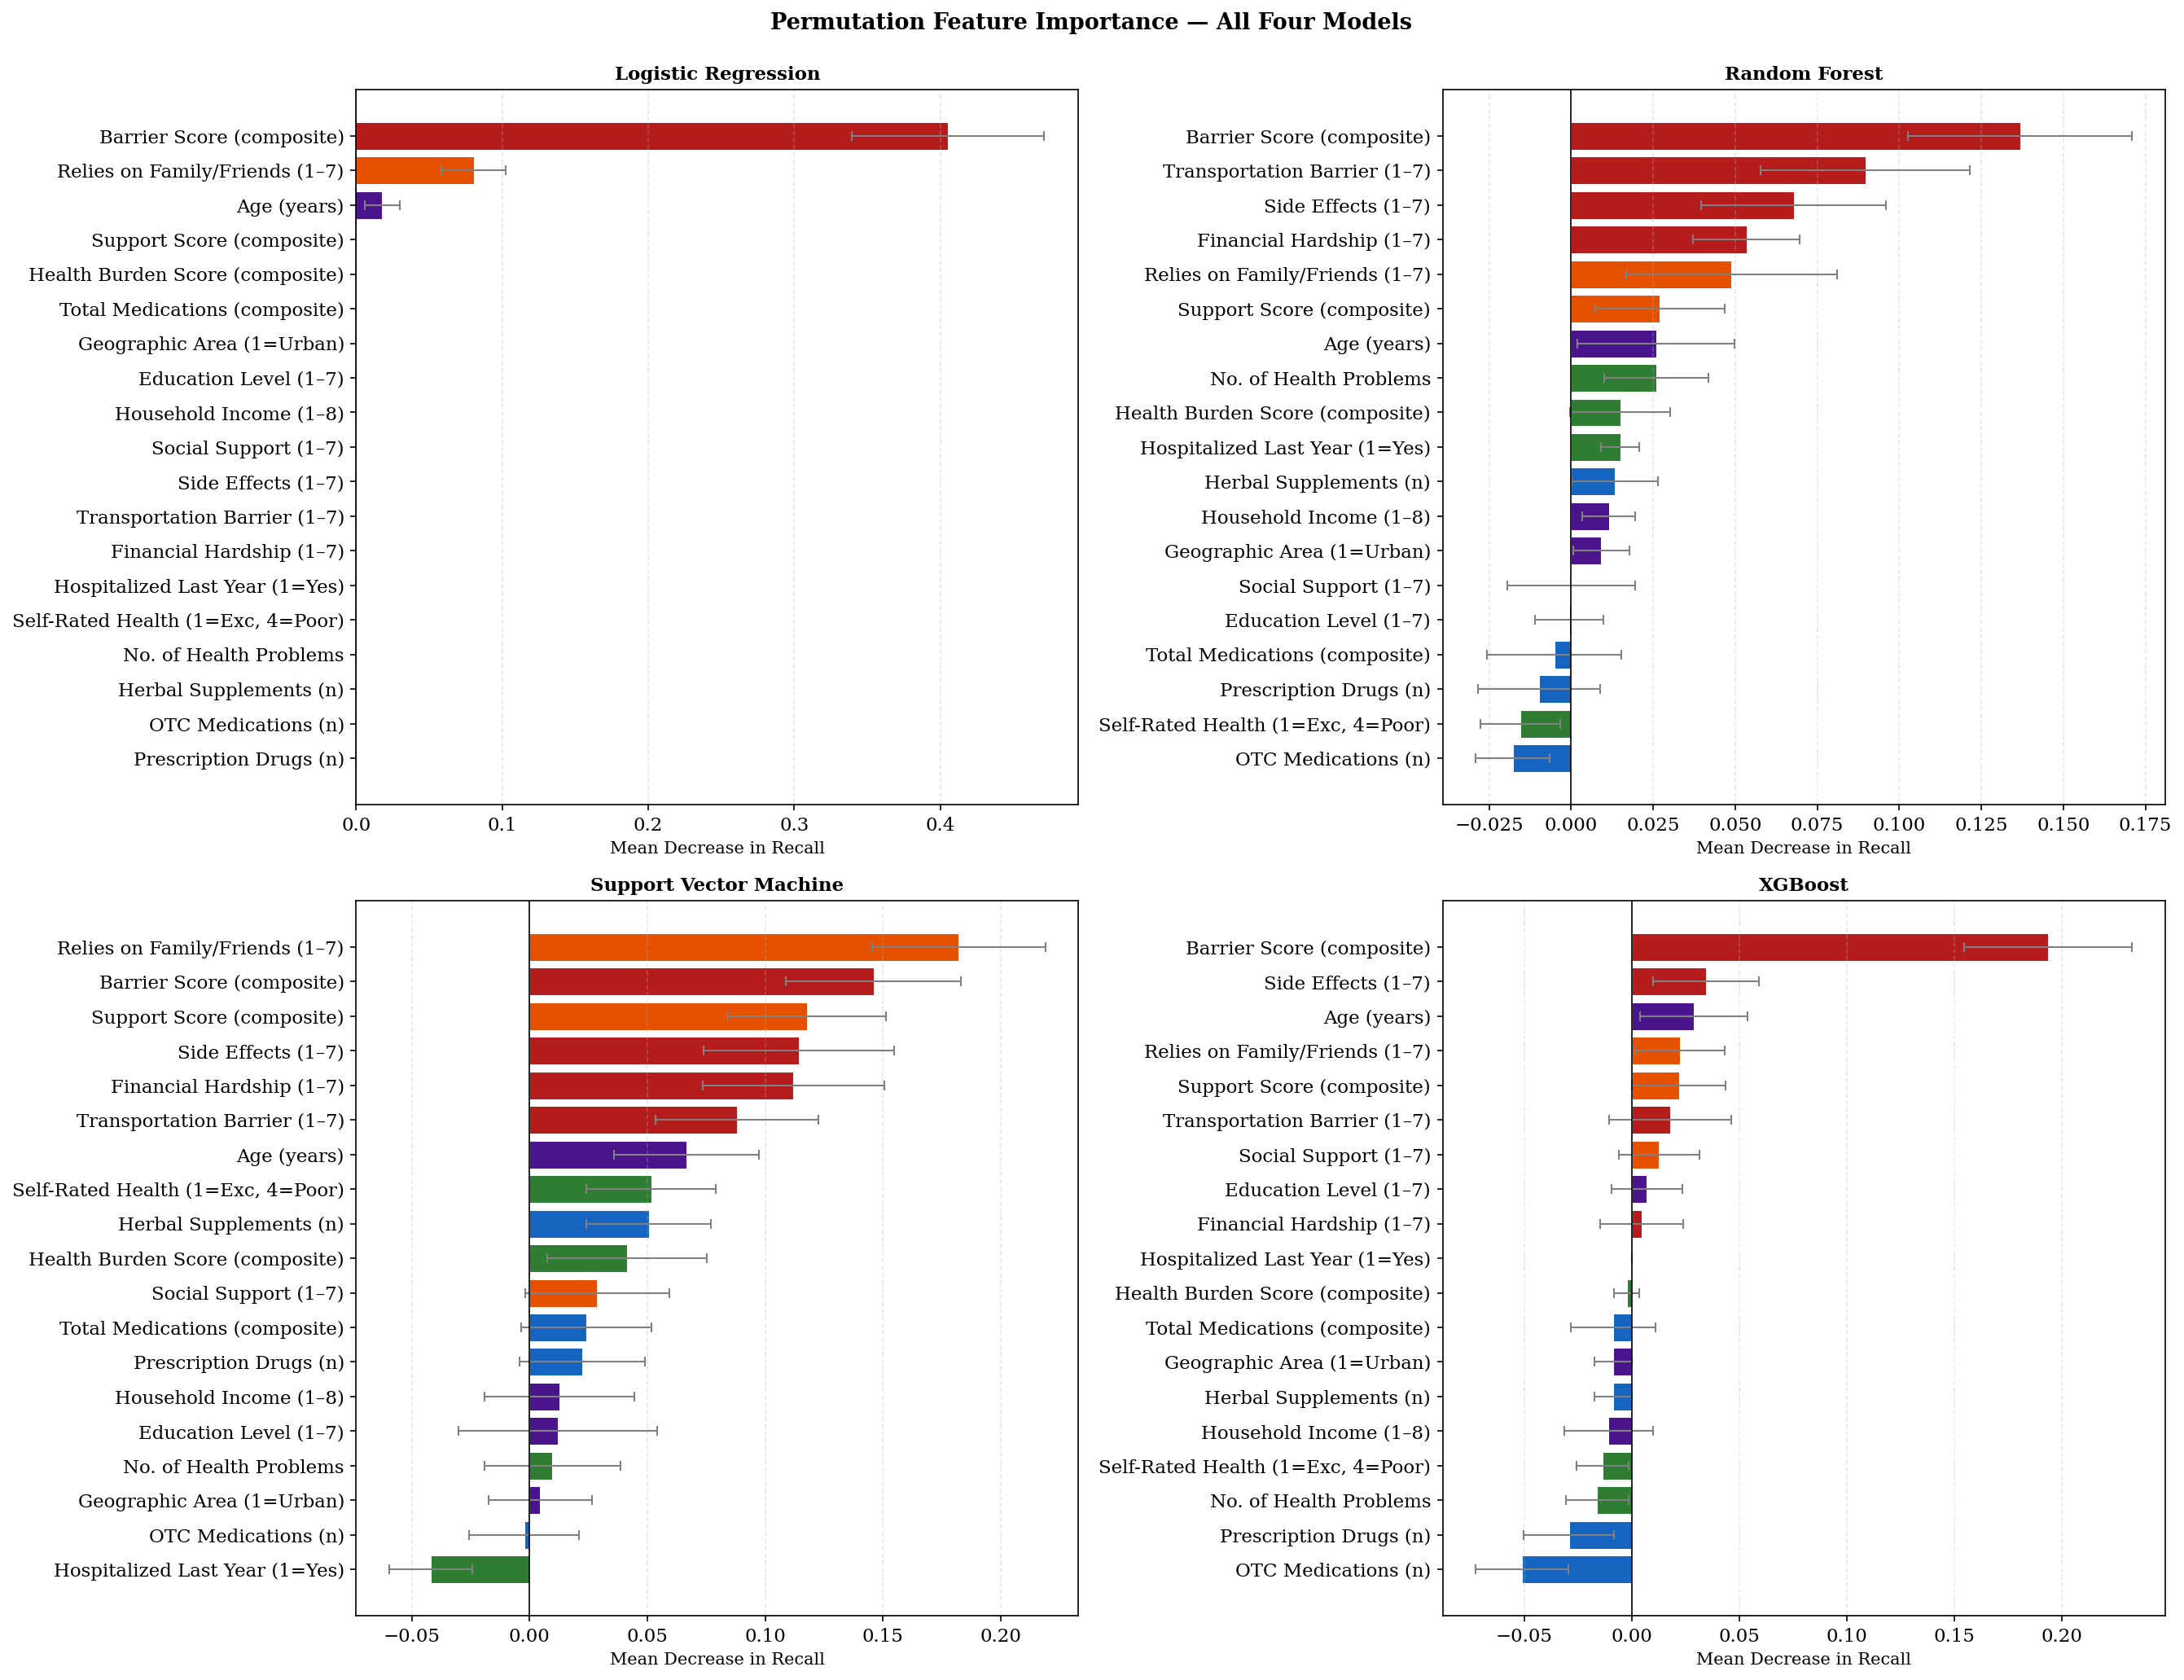


 Saved as 'fig10_permutation_importance.png'


In [43]:
# ═════════════════════════════════════════════════════════════════
# CELL 6.3: PERMUTATION FEATURE IMPORTANCE (Model-Agnostic)
# ═════════════════════════════════════════════════════════════════
# Permutation importance is a model-agnostic method that works
# for ALL four models including Logistic Regression and SVM.
#
# How it works:
#   1. Record baseline model performance on test set
#   2. Randomly SHUFFLE one feature column (breaking its relationship
#      with the target while leaving all others intact)
#   3. Measure how much performance DROPS
#   4. A large drop = the feature is very important
#   5. A small drop = the feature contributes little
#
# This is more reliable than tree-based importance because it
# measures actual predictive contribution on the TEST set,
# not training-time behavior.
# ═════════════════════════════════════════════════════════════════

from sklearn.inspection import permutation_importance

print("Computing permutation importance for all models...")
print("(This may take a few minutes)\n")

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
axes = axes.flatten()

perm_results = {}
for ax, (name, model) in zip(axes, [
    ('Logistic Regression', lr_best), ('Random Forest', rf_best),
    ('Support Vector Machine', svm_best), ('XGBoost', xgb_best)
]):
    perm = permutation_importance(
        model, X_test_scaled, y_test,
        n_repeats    = 30,
        random_state = 42,
        scoring      = 'recall',
        n_jobs       = -1
    )
    perm_df = pd.DataFrame({
        'Feature'  : PREDICTORS,
        'Mean'     : perm.importances_mean,
        'Std'      : perm.importances_std,
        'Label'    : [LABEL_MAP[p] for p in PREDICTORS]
    }).sort_values('Mean', ascending=True)

    perm_results[name] = perm_df
    colors = [cat_colors[f] for f in perm_df['Feature']]

    ax.barh(perm_df['Label'], perm_df['Mean'], xerr=perm_df['Std'],
            color=colors, edgecolor='white', linewidth=0.5,
            error_kw=dict(ecolor='gray', capsize=3, linewidth=1))
    ax.axvline(x=0, color='black', linestyle='-', lw=0.8)
    ax.set_xlabel('Mean Decrease in Recall', fontsize=10)
    ax.set_title(name, fontsize=11, fontweight='bold')
    ax.grid(axis='x', linestyle='--', alpha=0.3)
    print(f"  {name} — done")

fig.suptitle('Permutation Feature Importance — All Four Models\n',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig10_permutation_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n Saved as 'fig10_permutation_importance.png'")



---
# PHASE 7 — FINAL OUTPUTS

In [44]:
# ═════════════════════════════════════════════════════════════════
# CELL 7.1: DETAILED CLASSIFICATION REPORTS — ALL MODELS
# ═════════════════════════════════════════════════════════════════


print(" CLASSIFICATION REPORTS — ALL FOUR MODELS")
print("=" * 65)
for name, (preds, _) in all_models.items():
    print(f"\n{'─' * 65}")
    print(f"  {name}")
    print(f"{'─' * 65}")
    print(classification_report(
        y_test, preds,
        target_names=['Low Risk (0)', 'High Risk (1)']
    ))



 CLASSIFICATION REPORTS — ALL FOUR MODELS

─────────────────────────────────────────────────────────────────
  Logistic Regression
─────────────────────────────────────────────────────────────────
               precision    recall  f1-score   support

 Low Risk (0)       0.95      0.80      0.87       247
High Risk (1)       0.49      0.81      0.61        58

     accuracy                           0.80       305
    macro avg       0.72      0.81      0.74       305
 weighted avg       0.86      0.80      0.82       305


─────────────────────────────────────────────────────────────────
  Random Forest
─────────────────────────────────────────────────────────────────
               precision    recall  f1-score   support

 Low Risk (0)       0.90      0.94      0.91       247
High Risk (1)       0.66      0.53      0.59        58

     accuracy                           0.86       305
    macro avg       0.78      0.73      0.75       305
 weighted avg       0.85      0.86      0.85

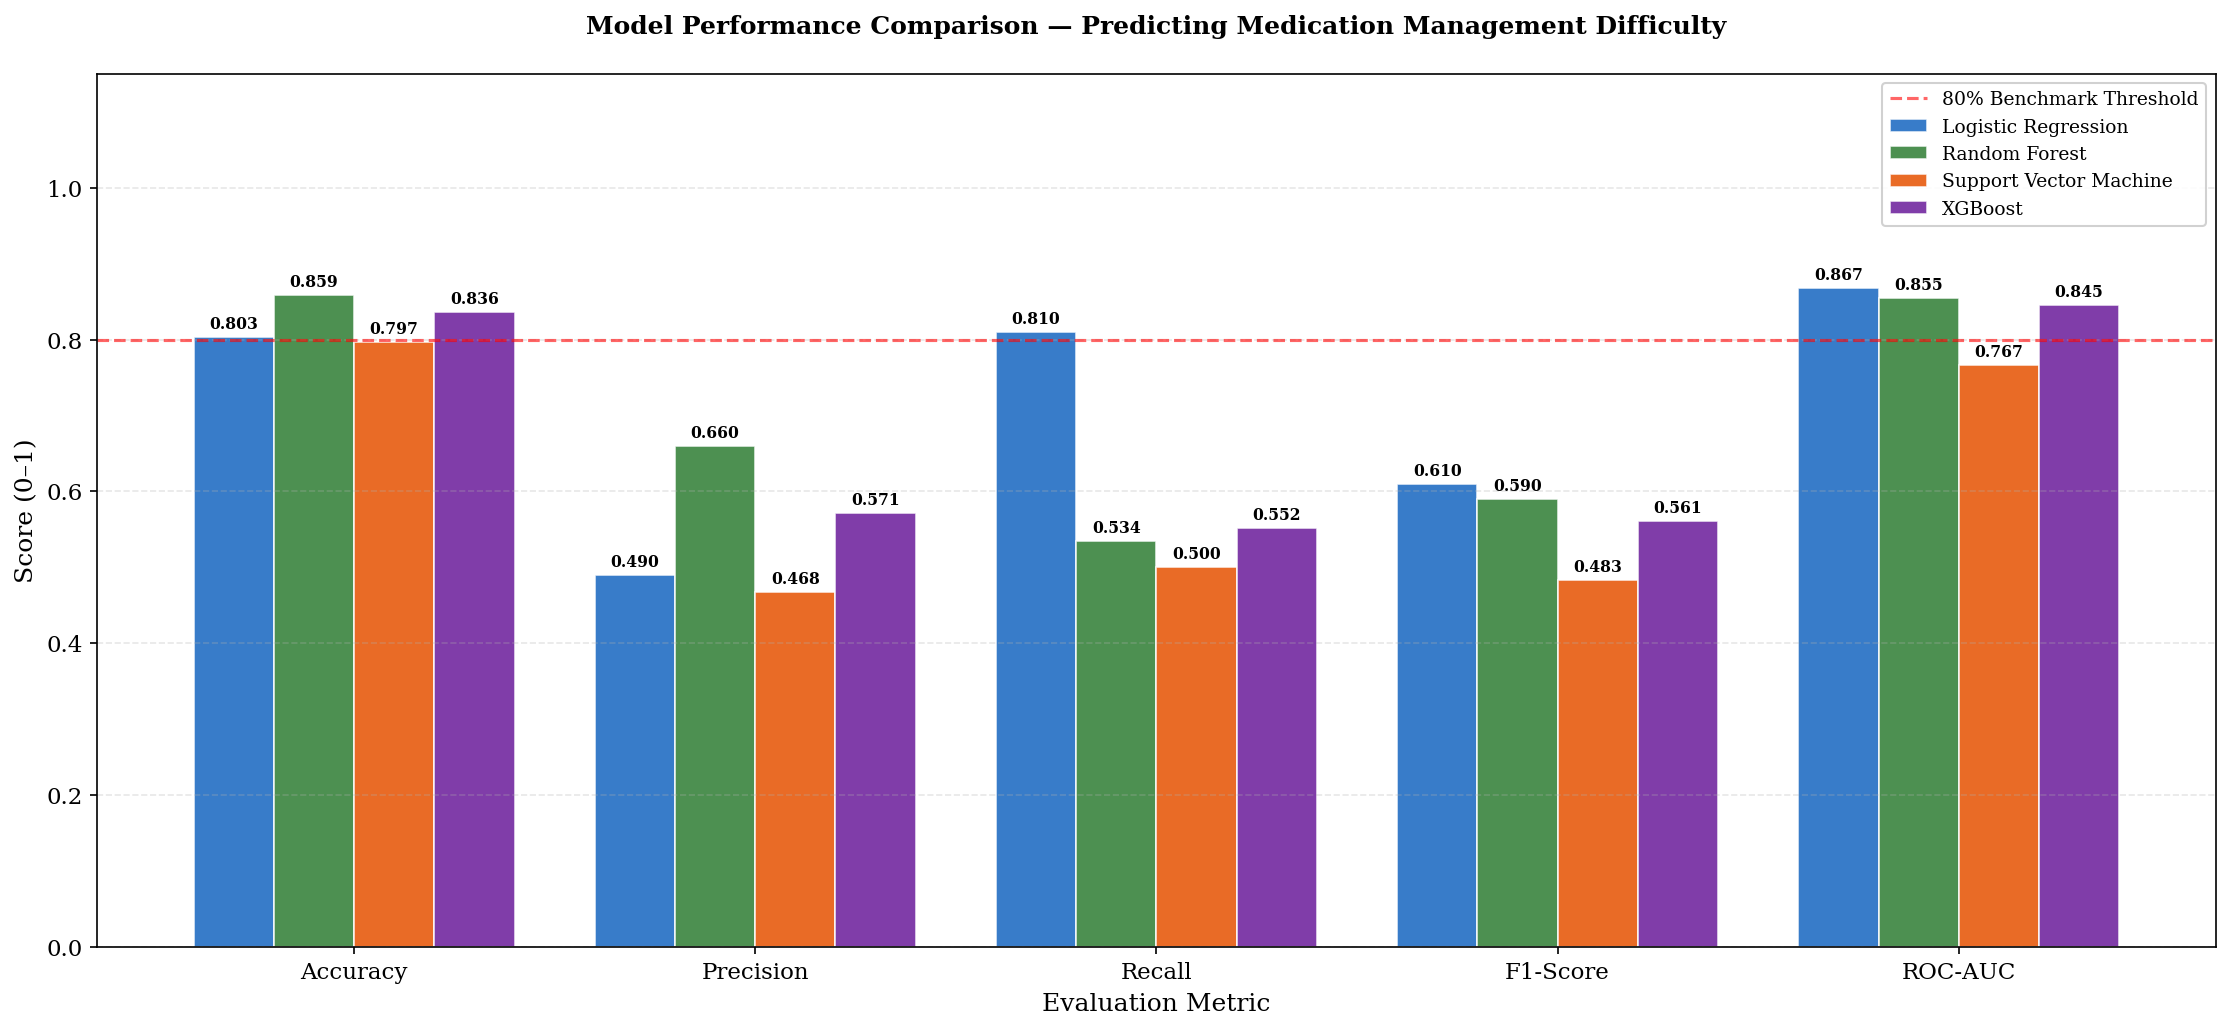

 Saved as 'fig11_model_comparison.png'


In [45]:
# ═════════════════════════════════════════════════════════════════
# CELL 7.2: FINAL PERFORMANCE COMPARISON CHART
# ═════════════════════════════════════════════════════════════════

metrics     = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
model_names = list(results.keys())
x           = np.arange(len(metrics))
width       = 0.20
bar_colors  = ['#1565C0', '#2E7D32', '#E65100', '#6A1B9A']

fig, ax = plt.subplots(figsize=(15, 7))

for i, (name, color) in enumerate(zip(model_names, bar_colors)):
    values = [results[name][m] for m in metrics]
    bars   = ax.bar(x + i * width, values, width, label=name,
                    color=color, alpha=0.85, edgecolor='white', linewidth=0.8)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.006,
                f'{val:.3f}', ha='center', va='bottom',
                fontsize=7.5, fontweight='bold')

ax.axhline(y=0.80, color='red', linestyle='--', lw=1.5,
           alpha=0.6, label='80% Benchmark Threshold')
ax.set_xlabel('Evaluation Metric', fontsize=12)
ax.set_ylabel('Score (0–1)', fontsize=12)
ax.set_title(
    'Model Performance Comparison — Predicting Medication Management Difficulty\n',
    fontsize=12, fontweight='bold'
)
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(0, 1.15)
ax.legend(loc='upper right', fontsize=9, framealpha=0.9)
ax.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig('fig11_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Saved as 'fig11_model_comparison.png'")



In [49]:
# ═════════════════════════════════════════════════════════════════
# CELL 7.3: FINAL SUMMARY
# ═════════════════════════════════════════════════════════════════
best_recall = max(results, key=lambda m: results[m]['Recall'])
best_f1     = max(results, key=lambda m: results[m]['F1-Score'])
best_acc    = max(results, key=lambda m: results[m]['Accuracy'])
best_auc    = max(results, key=lambda m: results[m]['ROC-AUC'])

print("=" * 70)
print("  FINAL SUMMARY — KEY FINDINGS")
print("=" * 70)
print(f"\n  Best RECALL (fewest missed high-risk patients):")
print(f"     → {best_recall:<30} Recall = {results[best_recall]['Recall']:.4f}")
print(f"\n  Best F1-SCORE (precision–recall balance):")
print(f"     → {best_f1:<30} F1 = {results[best_f1]['F1-Score']:.4f}")
print(f"\n  Best ACCURACY (overall correctness):")
print(f"     → {best_acc:<30} Accuracy = {results[best_acc]['Accuracy']:.4f}")
print(f"\n  Best ROC-AUC (overall discrimination):")
print(f"     → {best_auc:<30} AUC = {results[best_auc]['ROC-AUC']:.4f}")

print("\n" + "=" * 70)



  FINAL SUMMARY — KEY FINDINGS

  Best RECALL (fewest missed high-risk patients):
     → Logistic Regression            Recall = 0.8103

  Best F1-SCORE (precision–recall balance):
     → Logistic Regression            F1 = 0.6104

  Best ACCURACY (overall correctness):
     → Random Forest                  Accuracy = 0.8590

  Best ROC-AUC (overall discrimination):
     → Logistic Regression            AUC = 0.8674



In [50]:
import joblib

# Save to folder
folder = r'C:\Users\apugo\Desktop\Predicting Medication Non-Adherence Risk'

joblib.dump(lr_best, folder + r'\lr_model.pkl')
joblib.dump(scaler,  folder + r'\scaler.pkl')


['C:\\Users\\apugo\\Desktop\\Predicting Medication Non-Adherence Risk\\scaler.pkl']